# **<p style="text-align: center; color:black; background-color: orange; padding: 12px; margin: 0px;">🚗 Prédiction du prix des voitures d'occasion 🚗</p>**

## **1. Compréhension de la problématique**

### **Contexte métier**
Le marché de la voiture d'occasion est énorme mais très opaque : deux véhicules quasi identiques peuvent être affichés à des prix très différents selon le vendeur, la région ou simplement l'expérience de celui qui poste l'annonce. Pour un particulier comme pour un professionnel, fixer le **bon prix** est difficile : trop haut et l'annonce ne part jamais, trop bas et on perd de l'argent.

Le jeu de données utilisé ici provient d'annonces de voitures d'occasion postées sur eBay (Allemagne). L'idée est d'utiliser le **Machine Learning** pour estimer automatiquement un prix « juste » à partir des caractéristiques d'un véhicule (marque, modèle, kilométrage, puissance, âge, type de boîte, carburant, état...).

### **Rôle du ML & traduction en tâche ML**
La variable que l'on cherche à prédire est le **`price`** (le prix en euros), qui est une grandeur **continue**. Il s'agit donc clairement d'un problème de **régression supervisée**, et non de classification.

- **Entrée (X)** : les caractéristiques de la voiture.
- **Sortie (y)** : le prix estimé (`price`).
- **Métriques** : on suivra le $R^2$ (part de variance expliquée), la **MAE** (erreur moyenne en €, facile à interpréter pour le métier) et la **RMSE/MSE**.

### **2. État de l'art (étude bibliographique)**
La prédiction de prix sur données **tabulaires** est un problème très étudié. Les principales familles d'approches :

- **Modèles linéaires** (Régression linéaire, Ridge, Lasso) : simples et interprétables, mais ils captent mal les relations non linéaires (ex. l'effet de l'âge sur le prix n'est pas linéaire).
- **k plus proches voisins (KNN)** : non paramétrique, intuitif, mais sensible à l'échelle des variables et coûteux à grande échelle.
- **Arbres de décision** : capturent les non-linéarités et les interactions, mais sur-apprennent facilement seuls.
- **Méthodes d'ensemble (bagging / boosting)** : c'est aujourd'hui l'état de l'art sur les données tabulaires.
  - *Bagging* → **Random Forest** (Breiman, 2001), **Extra Trees**.
  - *Boosting* → **AdaBoost** (Freund & Schapire), **Gradient Boosting** (Friedman, 2001), puis ses implémentations modernes : **XGBoost** (Chen & Guestrin, 2016), **LightGBM** et **CatBoost** (Prokhorenkova et al., 2018), qui dominent régulièrement les compétitions Kaggle sur ce type de données.
- **Réseaux de neurones profonds (DNN)** : performants sur l'image/texte, mais sur des données tabulaires de taille moyenne ils sont souvent égalés voire dépassés par le gradient boosting (cf. Grinsztajn et al., 2022).
- **Explicabilité (XAI)** : **SHAP** (Lundberg & Lee, 2017) est devenu la référence pour expliquer la contribution de chaque variable à la prédiction.

### **Plan du notebook**
1. Analyse exploratoire (EDA) et compréhension des données
2. Prétraitement (valeurs manquantes, encodage, outliers, normalisation)
3. Modélisation : un DNN + plusieurs modèles de régression (≥ 10 algorithmes testés)
4. Explicabilité avec SHAP
5. **Pipeline reproductible, tuning des 3 modèles candidats et choix du modèle final**
6. **Sérialisation du pipeline complet (joblib)** pour le déploiement Streamlit


# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">📕 Bibliothèques 📕</p>**

In [1]:
import warnings, ydata_profiling, shap
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from tqdm import tqdm
from colorama import Fore, Back, Style

sns.set_style('dark')
warnings.filterwarnings('ignore')
shap.initjs()

ModuleNotFoundError: No module named 'ydata_profiling'

# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">📊 Analyse exploratoire & Prétraitement 📊</p>**

In [ ]:
df = pd.read_csv('/kaggle/input/uncovering-factors-that-affect-used-car-prices/autos.csv').drop('index', axis=1)
df.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    299468 non-nu

<Axes: >

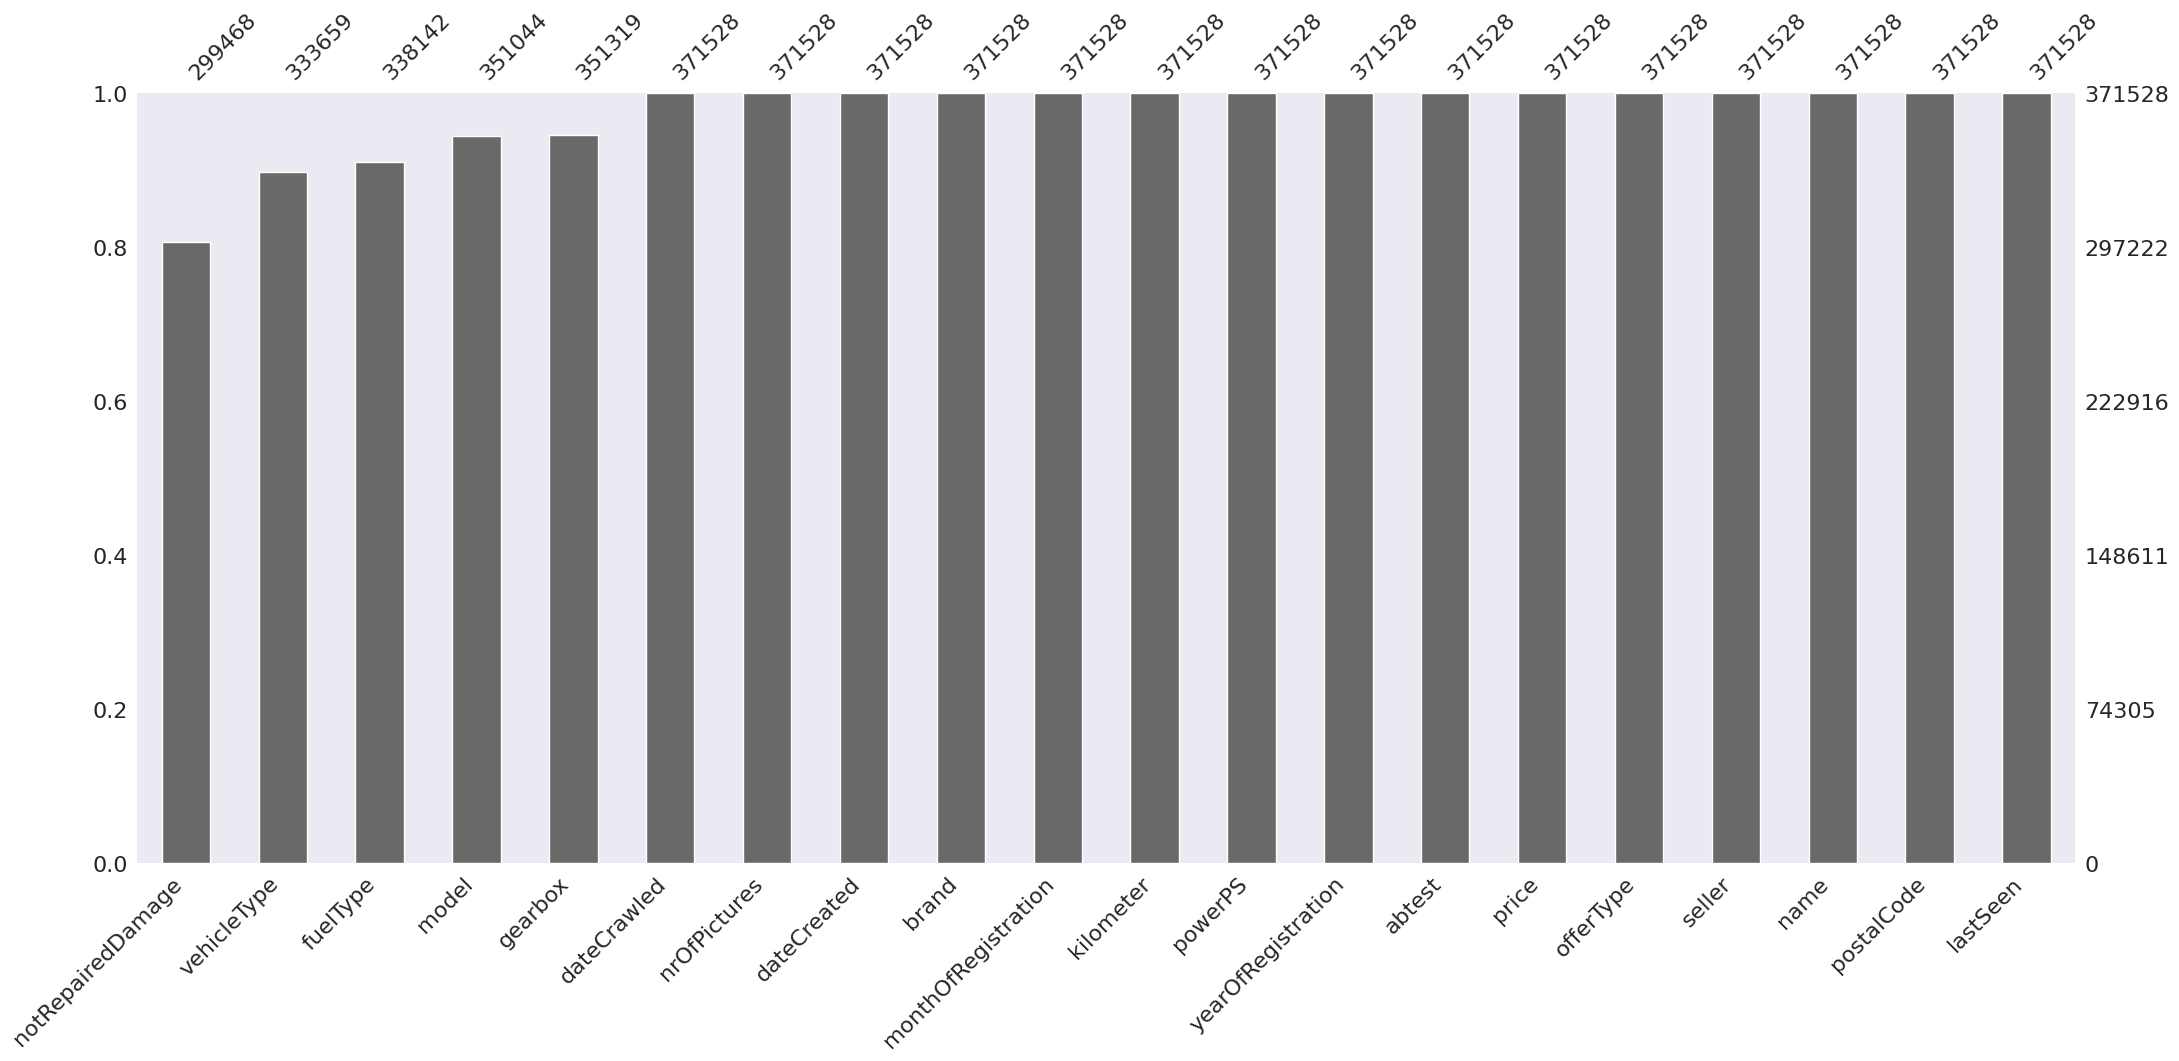

In [ ]:
msno.bar(df, sort='ascending')

In [ ]:
ydata_profiling.ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## **<p style='color: darkorange;  margin: 0px;'>Jusqu'ici, voici les problèmes que j'ai repérés dans les données :</p>**
- ### **Valeurs manquantes :**

    - **`vehicleType` : 37869 (10,2 %) valeurs manquantes**
    - **`gearbox` : 20209 (5,4 %) valeurs manquantes**
    - **`model` : 20484 (5,5 %) valeurs manquantes**
    - **`fuelType` : 33386 (9,0 %) valeurs manquantes**
    - **`notRepairedDamage` : 72060 (19,4 %) valeurs manquantes**


- ### **Dates**
    - **Le type de `dateCrawled`, `lastSeen` et `dateCreated` est `object` → à convertir en DateTime**


- ### **Zéros**

    - **`price` : 10778 (2,9 %) zéros**
    - **`powerPS` : 40820 (11,0 %) zéros**
    - **`monthOfRegistration` : 37675 (10,1 %) zéros**


- ### **Fortes corrélations**

    - **`price` est globalement très corrélé à `yearOfRegistration` et à une autre variable**
    - **`powerPS` est fortement corrélé à `price`**
    - **`vehicleType` est corrélé à `yearOfRegistration`**

- ### **Autres problèmes (possibles)**
    - **Valeurs catégorielles en allemand → à traduire en anglais**
    - **`nrOfPictures` est inutile → à supprimer**
    - **`dateCrawled` et `dateCreated` se ressemblent (le temps n'a pas d'importance ici) → probablement inutiles**
    - **Je me demande si la colonne `abtest` est pertinente ou non**

#### **<p style='margin: 0; color: cyan;'>Si c'était une vraie mission, j'aurais écrit un scraper qui irait récupérer le vehicleType, gearbox, model et fuelType à partir du modèle et de l'année pour compléter les manquants. Mais pour la partie EDA, je ne touche pas encore aux valeurs manquantes ni aux zéros.</p>**


<Axes: title={'center': 'Test Type'}>

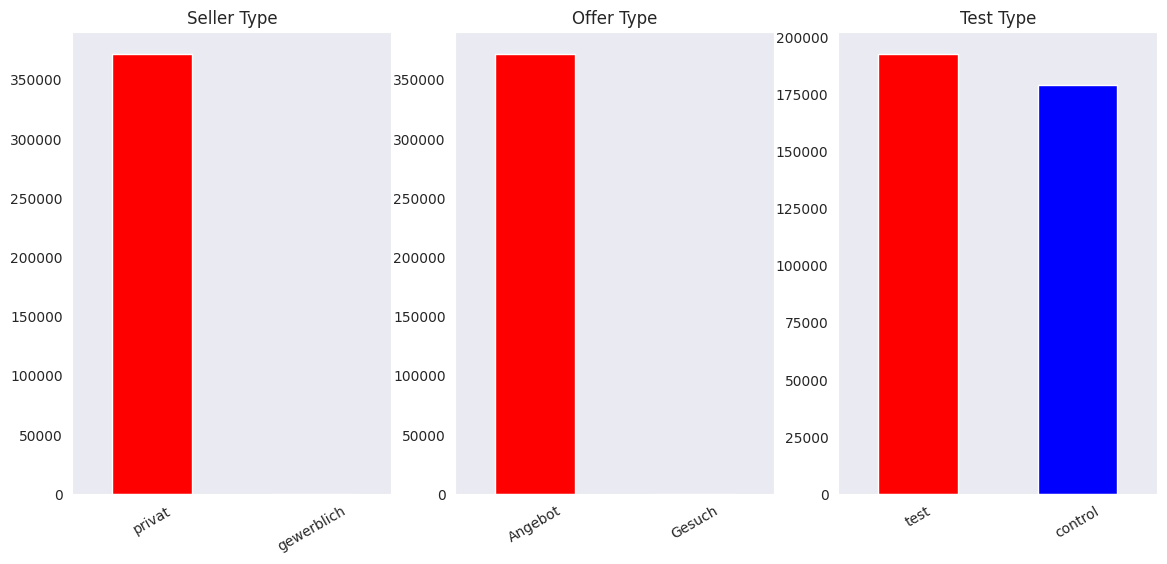

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

df['seller'].value_counts().plot(kind='bar', title='Seller Type',  color=['red', 'blue'], ax=axes[0], rot=30, xlabel='')

df['offerType'].value_counts().plot(kind='bar', title='Offer Type',  color=['red', 'blue'], ax=axes[1], rot=30, xlabel='')

df['abtest'].value_counts().plot(kind='bar', title='Test Type',  color=['red', 'blue'], ax=axes[2], rot=30, xlabel='')

## **<p style='margin: 0; color: darkorange;'>Prétraitement des données - Partie 1</p>**
- #### **Je pense que je devrai faire d'autres prétraitements plus loin.**
- #### **À part 3 lignes, toutes les annonces sont de particuliers : je supprime donc la colonne `seller`, inutile.**
- #### **La colonne `offerType` est elle aussi inutile, je la supprime également.**
- #### **La colonne `yearOfRegistration` contient des valeurs aberrantes. Je définis une plage solide : entre `1980` et `2023`.**
- #### **Traduction allemand → anglais :**
    - **manuell → Manual**
    - **automatik → Automatic**
    - **ja → Yes**
    - **nein → No**
    - **benzin → Petrol**
    - **andere → Other**


In [ ]:
# 1. Conversion des dates --> on supprime 'dateCrawled' et 'lastSeen'
df.drop(['lastSeen', 'dateCrawled'], axis=1, inplace=True)
df['dateCreated'] = pd.to_datetime(df['dateCreated'])

# 2. Suppression des colonnes 'nrOfPictures', 'seller', 'offerType'
df.drop('nrOfPictures', axis=1, inplace=True)
df.drop('seller', axis=1, inplace=True)
df.drop('offerType', axis=1, inplace=True)

# 3. On borne 'yearOfRegistration' à une plage raisonnable
df = df[df['yearOfRegistration'].between(1980, 2023)]

# 4. Allemand -> anglais, du mieux que je peux
df['gearbox'] = df['gearbox'].apply(lambda g: 'Manual' if g == 'manuell' else 'Automatic')
df['notRepairedDamage'] = df['notRepairedDamage'].apply(lambda g: 'Yes' if g == 'ja' else 'No' if g =='nein' else 'NaN')
df.loc[df['fuelType'] == 'benzin', 'fuelType'] = 'Petrol'
df.loc[df['fuelType'] == 'andere', 'fuelType'] = 'Other'

df.head()

,name,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,postalCode
0,Golf_3_1.6,480,test,NaN,1993,Manual,0,golf,150000,0,Petrol,volkswagen,NaN,2016-03-24,70435
1,A5_Sportback_2.7_Tdi,18300,test,coupe,2011,Manual,190,NaN,125000,5,diesel,audi,Yes,2016-03-24,66954
2,"Jeep_Grand_Cherokee_""Overland""",9800,test,suv,2004,Automatic,163,grand,125000,8,diesel,jeep,NaN,2016-03-14,90480
3,GOLF_4_1_4__3TÜRER,1500,test,kleinwagen,2001,Manual,75,golf,150000,6,Petrol,volkswagen,No,2016-03-17,91074
4,Skoda_Fabia_1.4_TDI_PD_Classic,3600,test,kleinwagen,2008,Manual,69,fabia,90000,7,diesel,skoda,No,2016-03-31,60437


In [ ]:
colors_10_1 = sns.color_palette("Spectral", 10)
colors_10_2 = sns.color_palette("Set3", 10)
colors_5 = sns.color_palette('Accent', 5)

<Axes: title={'center': 'Bottom 10 Brands - Ads Count'}, xlabel='Brand', ylabel='Count'>

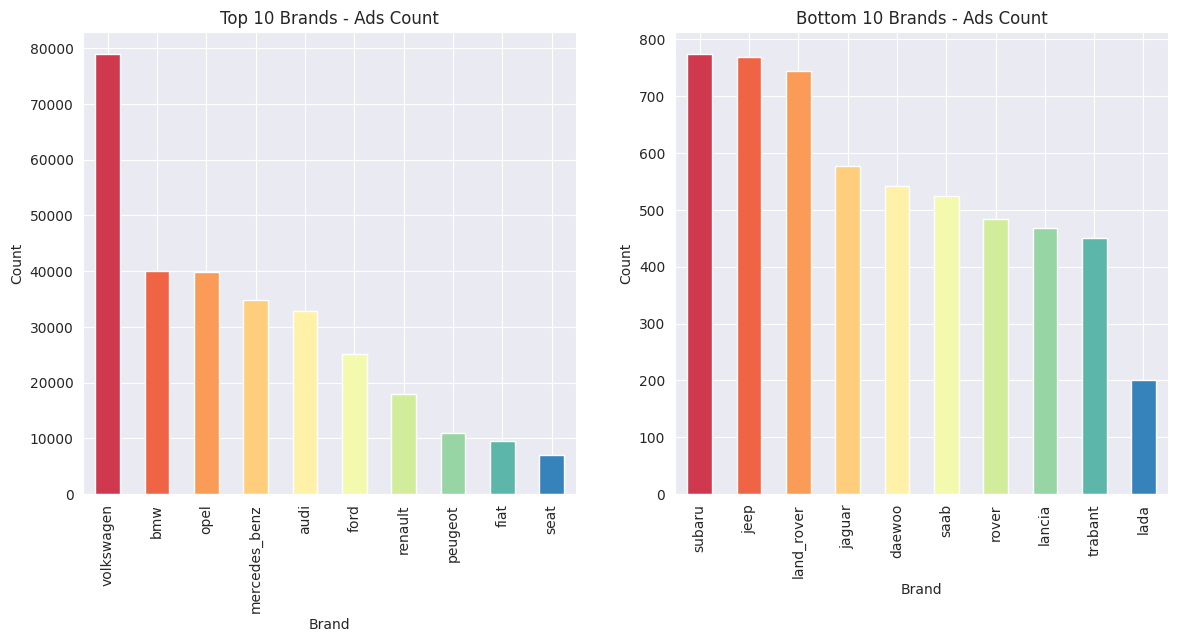

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

df['brand'].value_counts().head(10).plot(kind='bar', title='Top 10 Brands - Ads Count', color=colors_10_1, ax=axes[0], xlabel='Brand', ylabel='Count', grid=True)
df['brand'].value_counts().tail(10).plot(kind='bar', title='Bottom 10 Brands - Ads Count', color=colors_10_1, ax=axes[1], xlabel='Brand', ylabel='Count', grid=True)

<Axes: title={'center': 'Bottom 10 Models by Brand - Ads Count'}, xlabel='(Brand, Model) Pairs', ylabel='Count'>

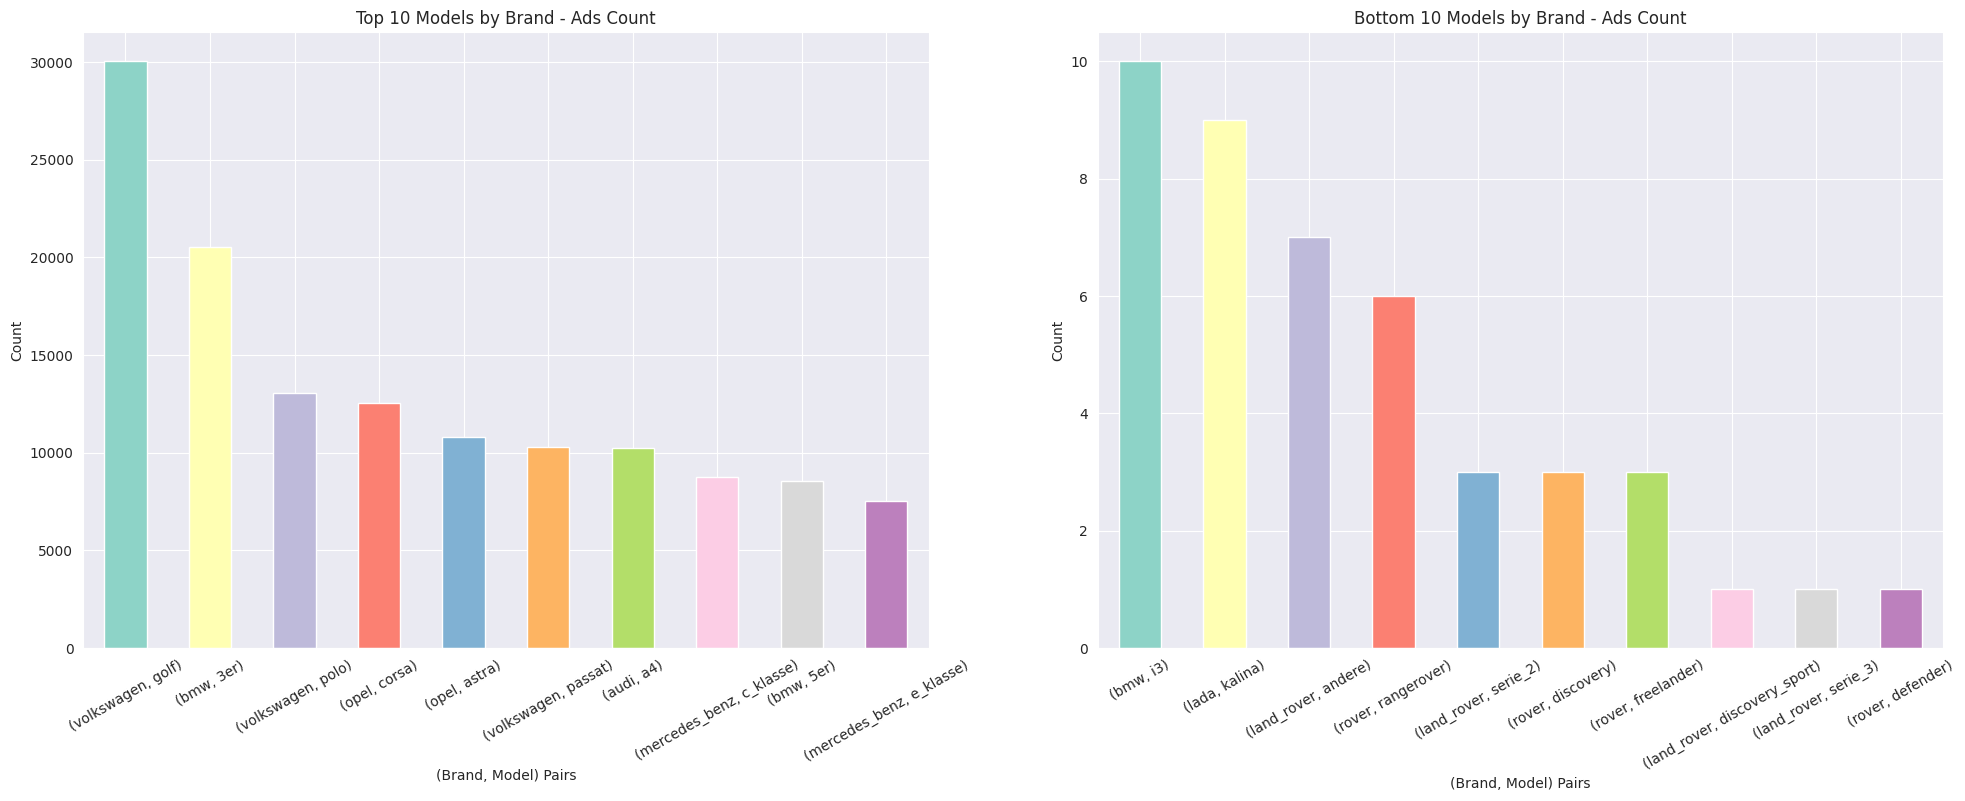

In [ ]:
group_by_brand = df.groupby('brand')['model'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

group_by_brand.head(10).plot(kind='bar', grid=True, rot=30, xlabel="(Brand, Model) Pairs", ylabel='Count', title='Top 10 Models by Brand - Ads Count', ax=axes[0], color=colors_10_2)
group_by_brand.tail(10).plot(kind='bar', grid=True, rot=30, xlabel="(Brand, Model) Pairs", ylabel='Count', title='Bottom 10 Models by Brand - Ads Count', ax=axes[1], color=colors_10_2)

<Axes: title={'center': 'Top 10 Cars by Vehicle Type, Brand, and Model - Ads Count'}, xlabel='vehicleType,model,brand'>

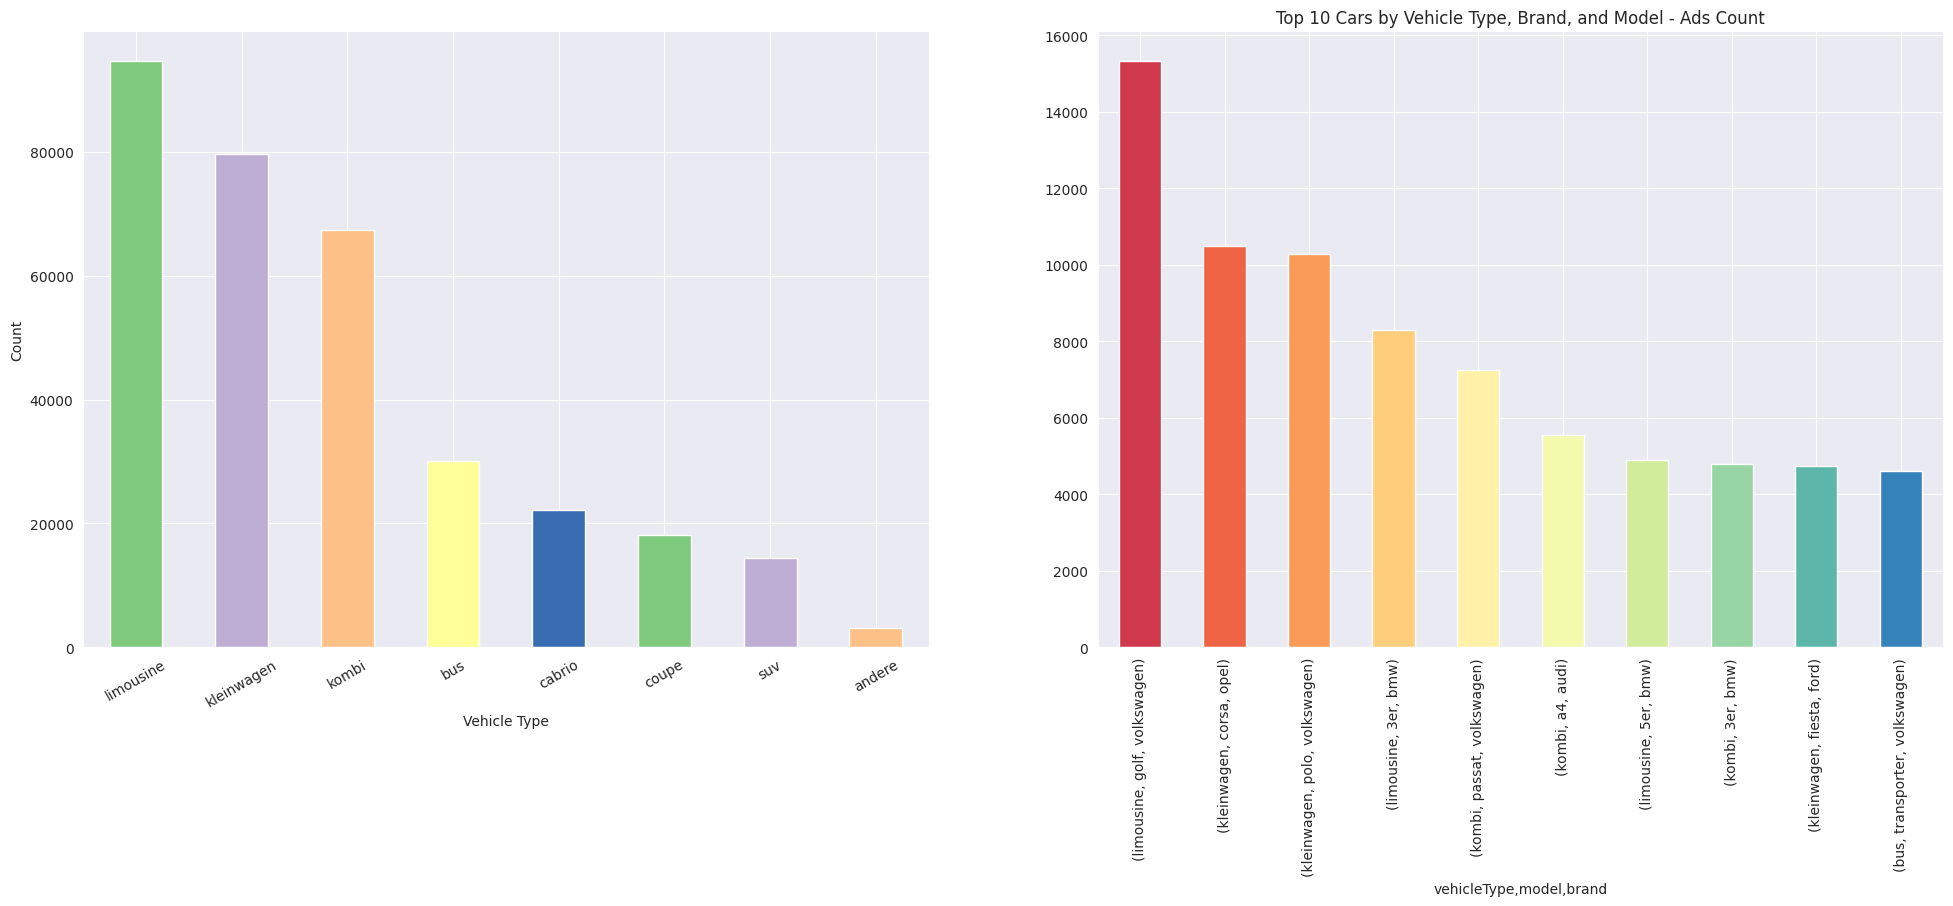

In [ ]:
group_by_vehicle_type = df.groupby('vehicleType')[['model', 'brand']].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

df['vehicleType'].value_counts().plot(kind='bar', color=colors_5, ax=axes[0], grid=True, rot=30, xlabel='Vehicle Type', ylabel='Count', title='')
group_by_vehicle_type.head(10).plot(kind='bar', grid=True, color=colors_10_1, ax=axes[1], title='Top 10 Cars by Vehicle Type, Brand, and Model - Ads Count')

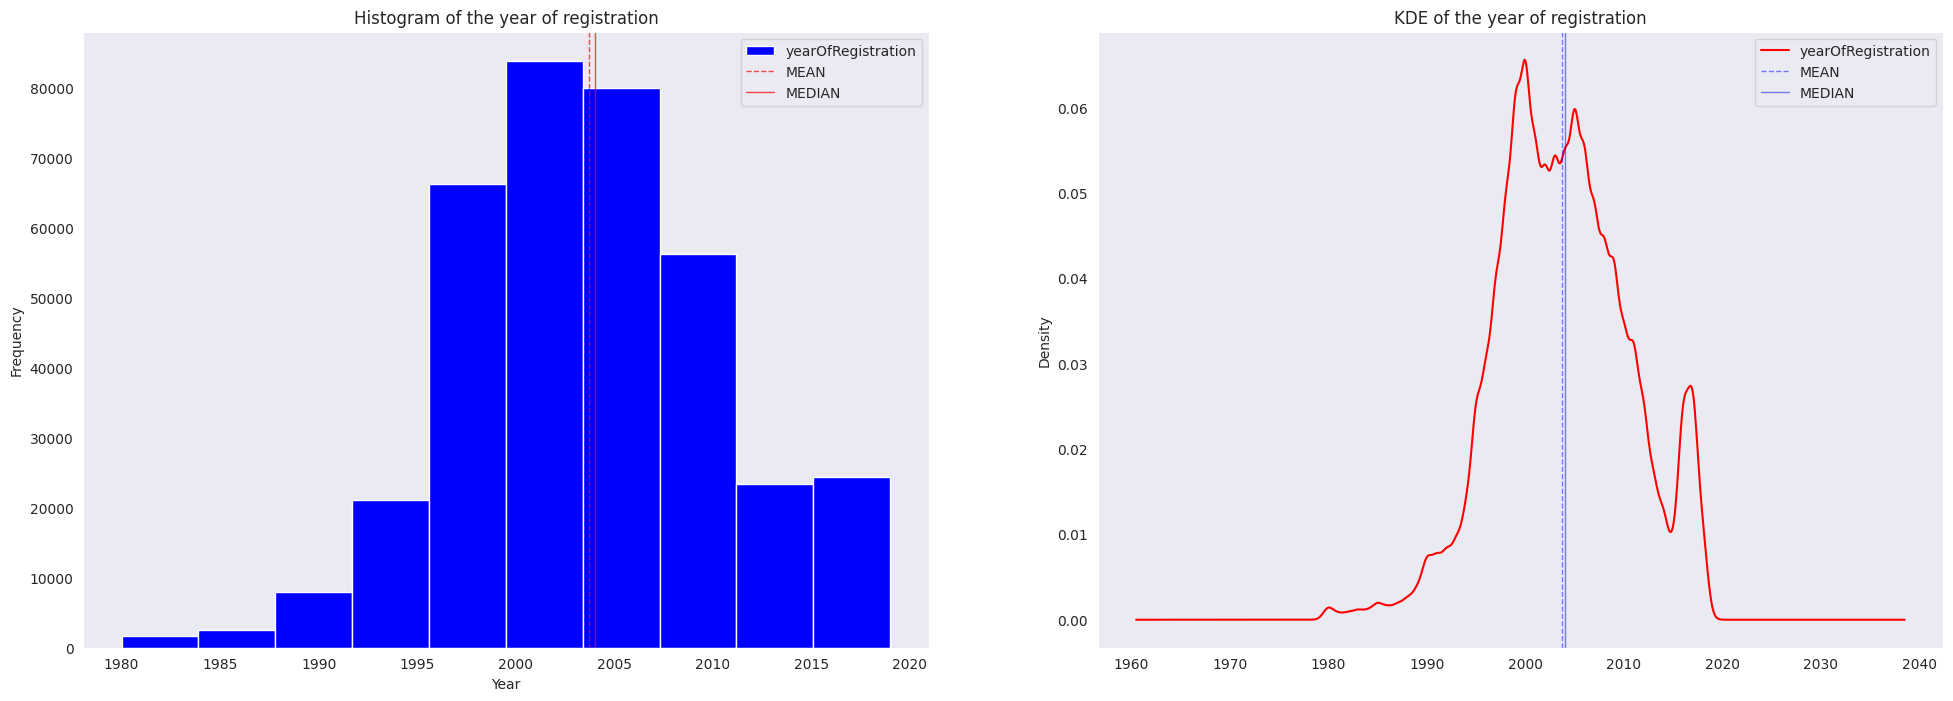

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

yr_mean = df['yearOfRegistration'].mean()
yr_median = df['yearOfRegistration'].median()

df['yearOfRegistration'].plot(kind='hist', bins=10, ax=axes[0], title='Histogram of the year of registration', xlabel='Year', color='blue')
axes[0].axvline(yr_mean, color='red', linestyle='dashed', linewidth=1, label='MEAN', alpha=.7)
axes[0].axvline(yr_median, color='red', linestyle='solid', linewidth=1, label='MEDIAN', alpha=.7)
axes[0].legend()

df['yearOfRegistration'].plot(kind='kde', ax=axes[1], title='KDE of the year of registration', xlabel='Year',  color='red')
axes[1].axvline(yr_mean, color='blue', linestyle='dashed', linewidth=1, label='MEAN', alpha=.5)
axes[1].axvline(yr_median, color='blue', linestyle='solid', linewidth=1, label='MEDIAN', alpha=.5)
axes[1].legend()

### **Il y a aussi un truc bizarre avec `kilometer`. Comme on le voit, la distribution est centrée autour de `150K` et il n'y a aucune valeur au-dessus. Les valeurs sont peu variées. Je laisse cette colonne telle quelle.**
**Min. du Kilométrage : 5 000 — Max. du Kilométrage : 150 000**


Min. of Kilometer: 5000 -- Max. of Kilometer: 150000



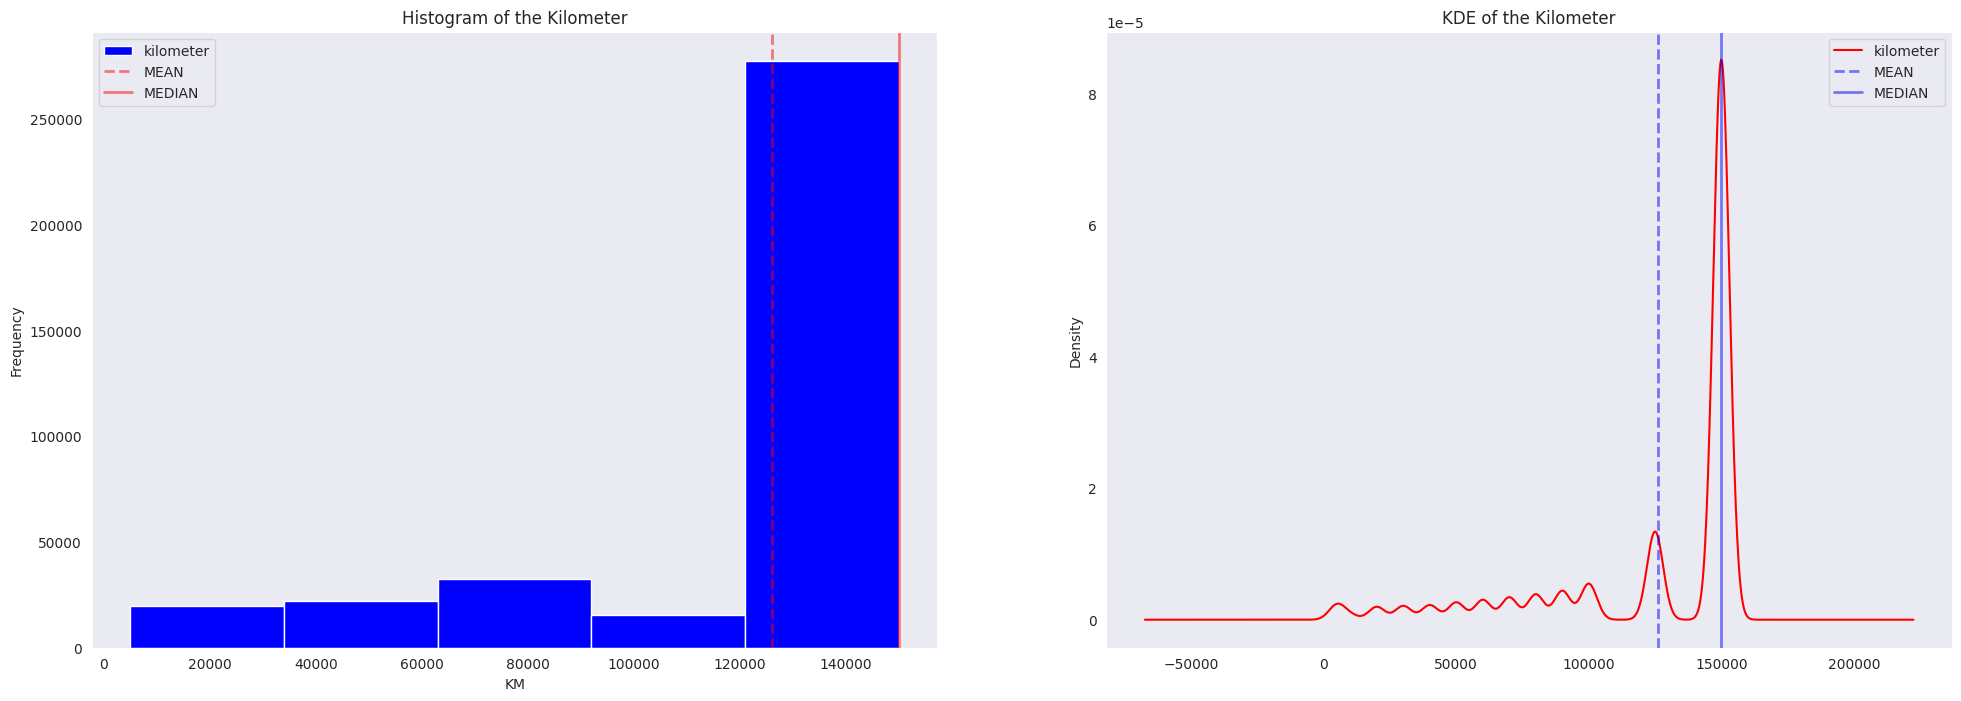

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

km_mean = df['kilometer'].mean()
km_median = df['kilometer'].median()

df['kilometer'].plot(kind='hist', bins= 5, ax=axes[0], title='Histogram of the Kilometer', xlabel='KM', color='blue')
axes[0].axvline(km_mean, color='red', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[0].axvline(km_median, color='red', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[0].legend()

df['kilometer'].plot(kind='kde', ax=axes[1], title='KDE of the Kilometer', xlabel='KM',  color='red')
axes[1].axvline(km_mean, color='blue', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[1].axvline(km_median, color='blue', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[1].legend()

print(f"Min. of Kilometer: {df['kilometer'].min()} -- Max. of Kilometer: {df['kilometer'].max()}\n")

### **Je pense qu'il faut supprimer les lignes dont le carburant est `lpg`, `cng`, `hybrid`, `other` ou `elektro`.**

<Axes: title={'center': 'Repaired/Damaged?'}, xlabel='Repaired/Damaged', ylabel='Count'>

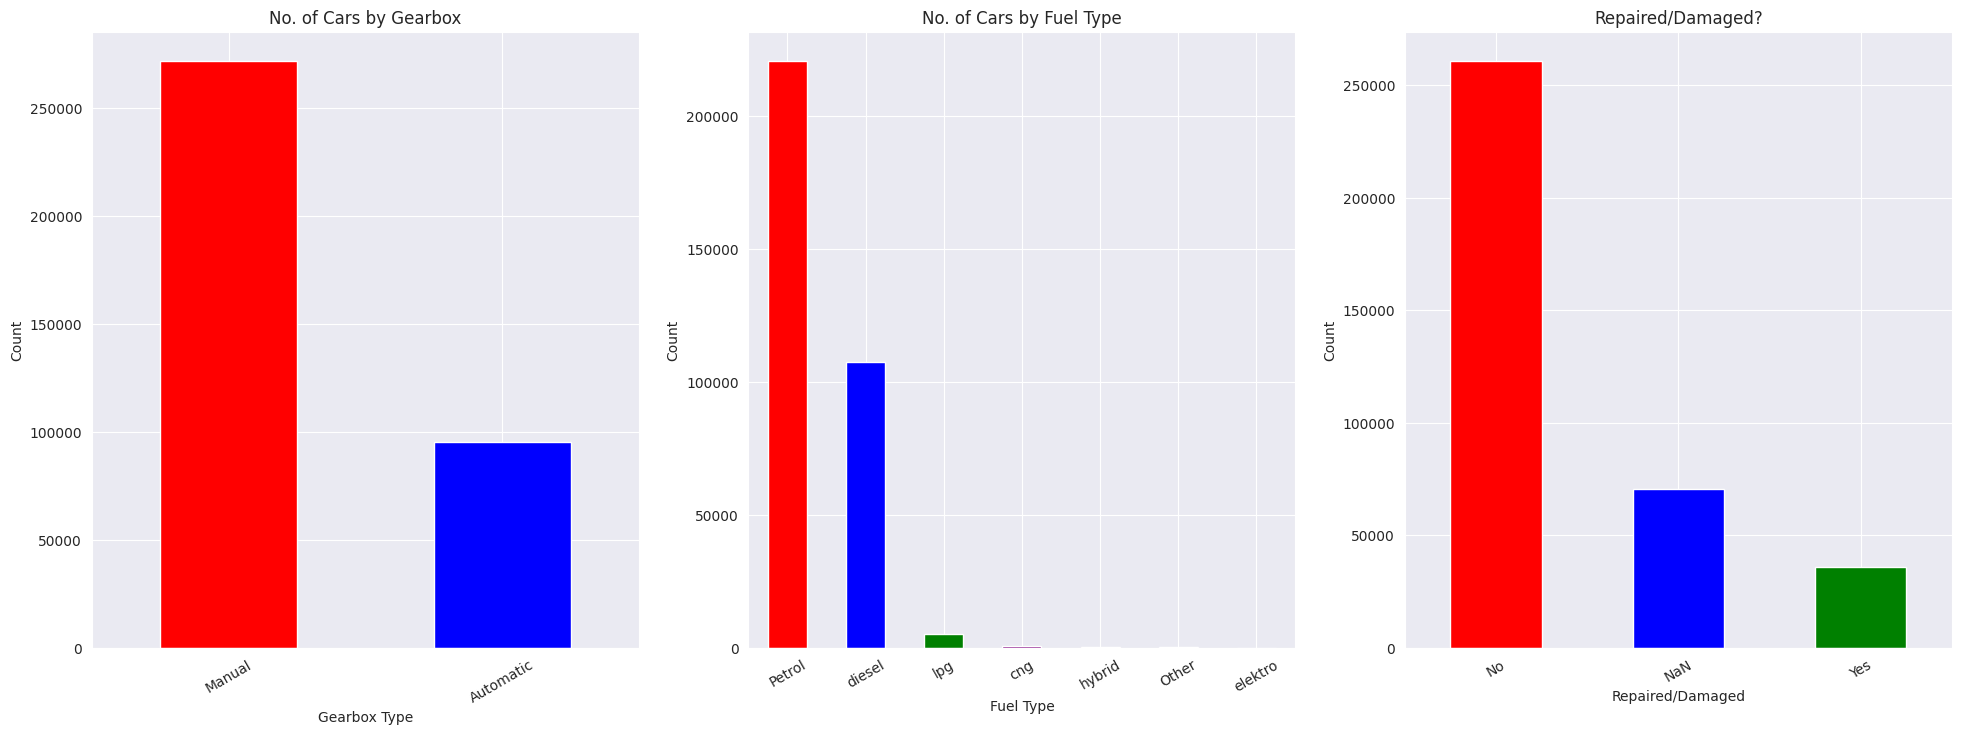

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8))

df['gearbox'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'blue'], title='No. of Cars by Gearbox', xlabel='Gearbox Type', ylabel='Count', rot=30, grid=True)
df['fuelType'].value_counts().plot(kind='bar', ax=axes[1], color=['red', 'blue', 'green', 'purple'], title='No. of Cars by Fuel Type', xlabel='Fuel Type', ylabel='Count', rot=30, grid=True)
df['notRepairedDamage'].value_counts().plot(kind='bar', ax=axes[2], color=['red', 'blue', 'green'], title='Repaired/Damaged?', xlabel='Repaired/Damaged', ylabel='Count', rot=30, grid=True)

<Axes: title={'center': 'KDE of the month of registration'}, ylabel='Density'>

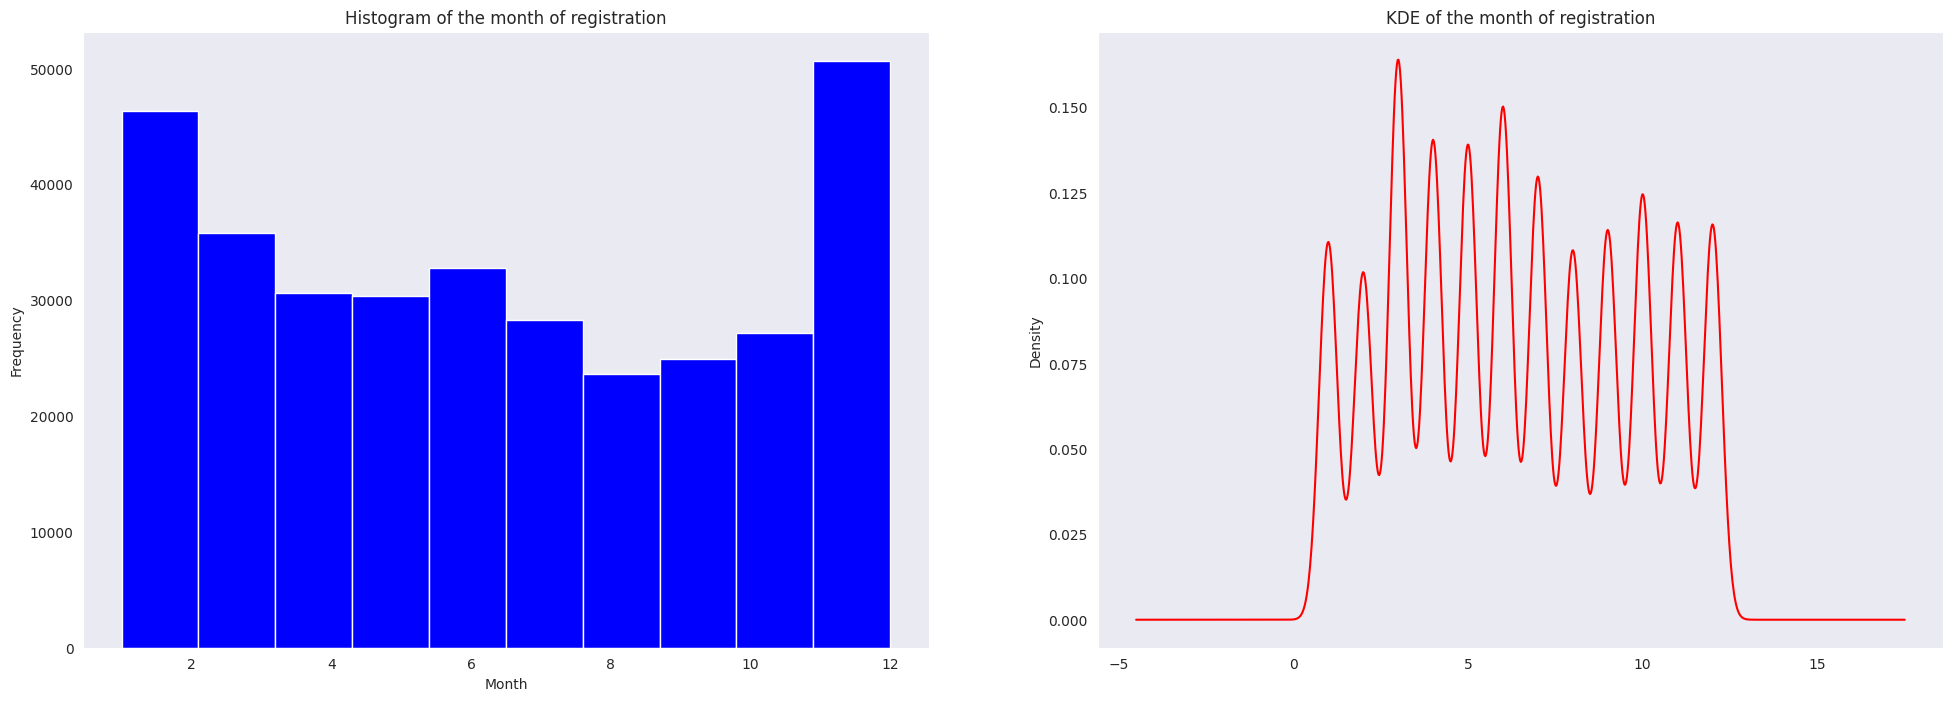

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

months = df[df['monthOfRegistration'] > 0]

months['monthOfRegistration'].plot(kind='hist', ax=axes[0], title='Histogram of the month of registration', xlabel='Month', color='blue')

months['monthOfRegistration'].plot(kind='kde', ax=axes[1], title='KDE of the month of registration', xlabel='Month', color='red')

### **Il n'y a aucune corrélation entre le prix et le mois d'immatriculation, je supprimerai donc cette colonne plus tard.**

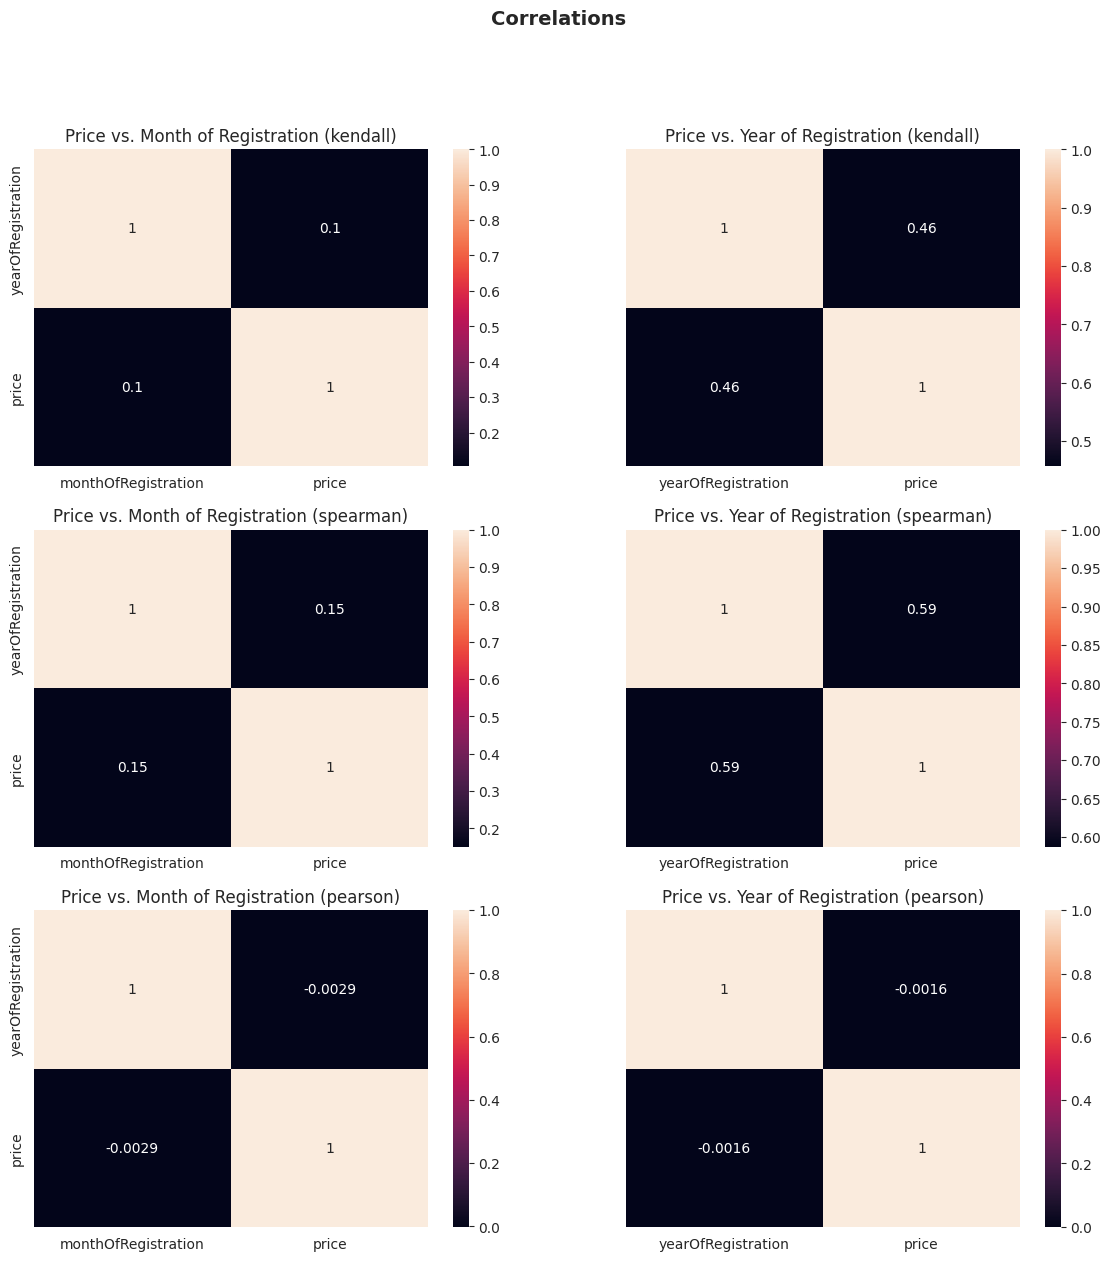

In [ ]:
a = df[['monthOfRegistration', 'price']]
b = df[['yearOfRegistration', 'price']]
methods = ['kendall', 'spearman', 'pearson']

fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharey=True)
fig.suptitle('Correlations', fontweight='bold', fontsize='14')

for i in range(3):
        
    sns.heatmap(a.corr(method=methods[i]), annot=True, ax=axes[i,0])
    axes[i,0].set_title(f"Price vs. Month of Registration ({methods[i]})")

    sns.heatmap(b.corr(method=methods[i]), annot=True, ax=axes[i,1])
    axes[i,1].set_title(f"Price vs. Year of Registration ({methods[i]})")

### **La plage de `price` me dérange :**

- **Nb de voitures à plus de 20K : 16 469**
- **Nb de voitures à plus de 30K : 5 556**
- **Nb de voitures à plus de 40K : 2 501**
- **Moyenne du prix : 16 611,7 — Médiane : 2 944,0**
- **Min. : 0 — Max. : 2 147 483 647**


In [ ]:
print(f"No. of cars with a price value higher than 20K: {Style.BRIGHT}{len(df[df['price'] > 20_000])}")
print(f"{Style.RESET_ALL}No. of cars with a price value higher than 30K: {Style.BRIGHT}{len(df[df['price'] > 30_000])}")
print(f"{Style.RESET_ALL}No. of cars with a price value higher than 40K: {Style.BRIGHT}{len(df[df['price'] > 40_000])}")
print(f"{Style.RESET_ALL}Mean of price: {Style.BRIGHT}{df['price'].mean():.2f}{Style.RESET_ALL}, Median of price: {Style.BRIGHT}{df['price'].median()}")
print(f"{Style.RESET_ALL}Min. price: {Style.BRIGHT}{df['price'].min()}{Style.RESET_ALL}, Max. price: {Style.BRIGHT}{df['price'].max()}")

No. of cars with a price value higher than 20K: 16469
No. of cars with a price value higher than 30K: 5556
No. of cars with a price value higher than 40K: 2501
Mean of price: 16611.71, Median of price: 2944.0
Min. price: 0, Max. price: 2147483647


### **Comme on le voit, la plage `[200, 20K]` est meilleure que les deux autres et élimine une grande partie des outliers. On pourrait descendre plus bas, mais je préfère m'arrêter là. À garder en tête : les prix sont asymétriques (skewed).**

In [ ]:
df['price'].quantile(.95), df['price'].quantile(.05)

(19500.0, 200.0)

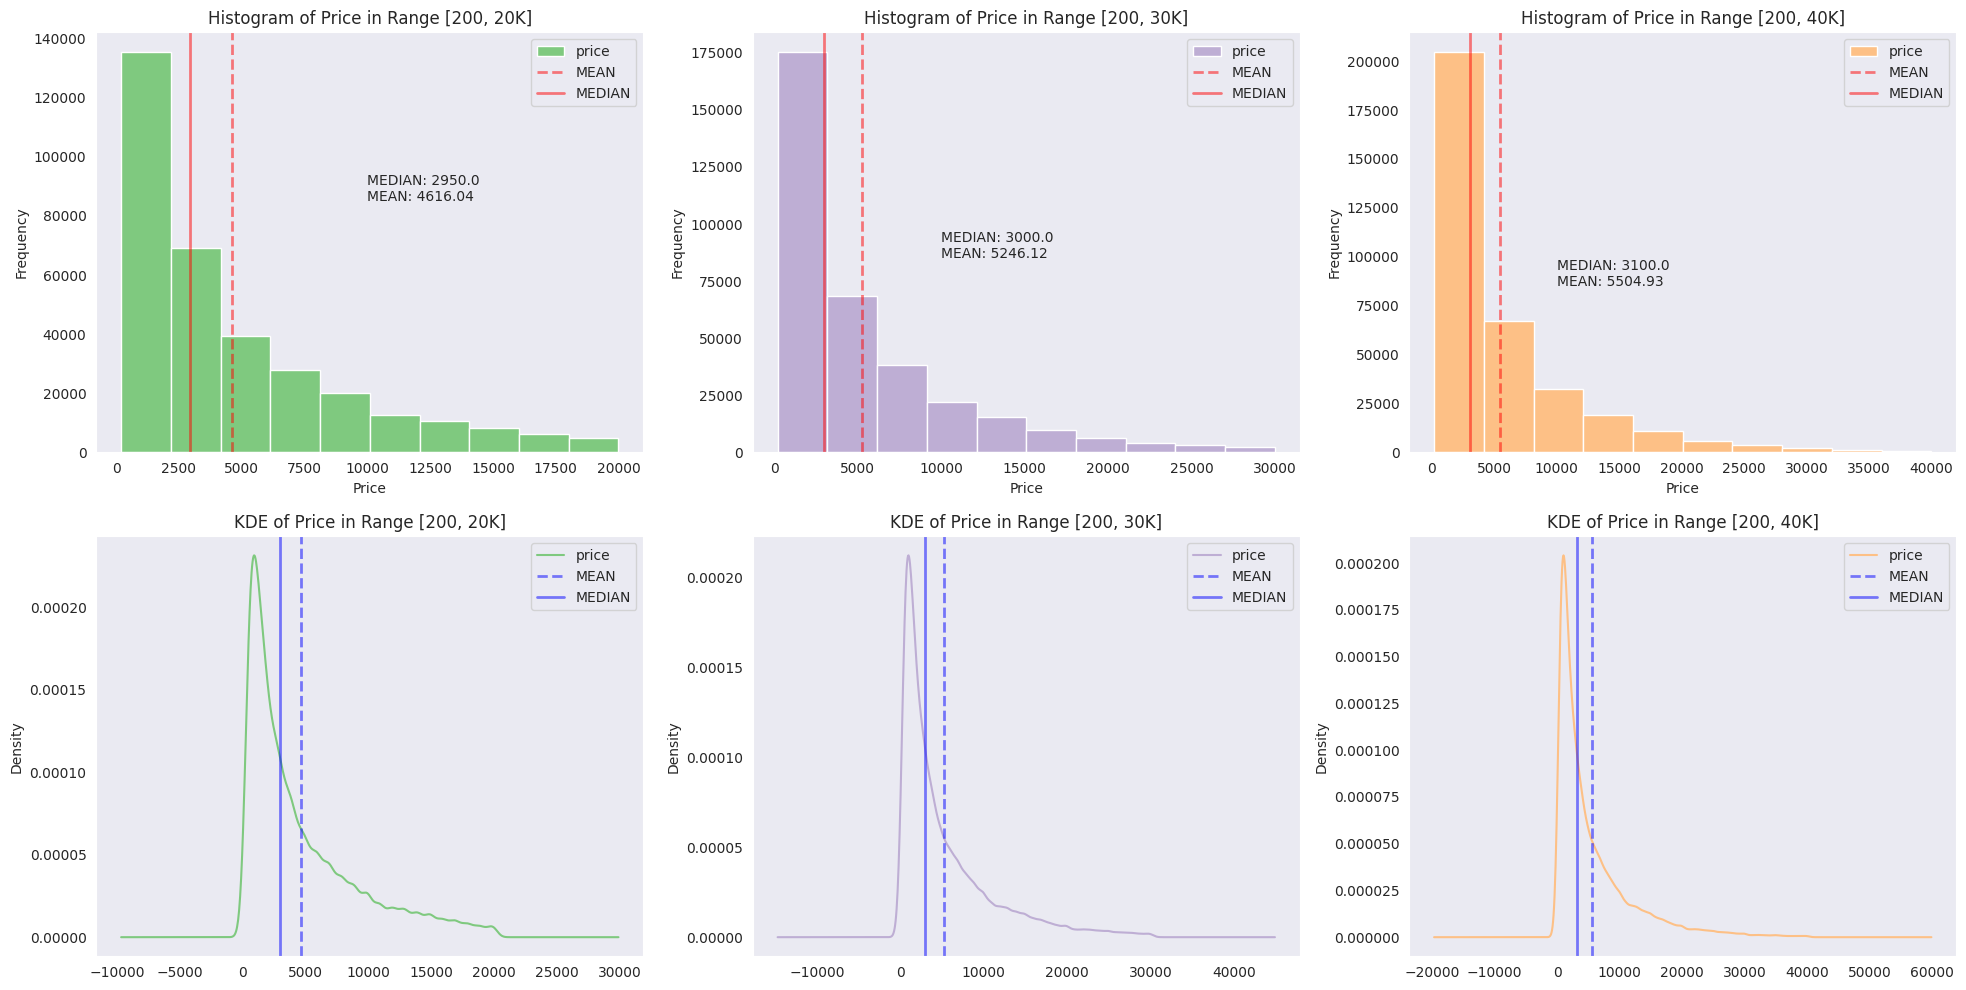

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))

bins = 10

price_20 = df.loc[df['price'].between(200, 20_000), 'price']
price_30 = df.loc[df['price'].between(200, 30_000), 'price']
price_40 = df.loc[df['price'].between(200, 40_000), 'price']

price_20.plot(kind='hist', bins=bins, ax=axes[0,0], title='Histogram of Price in Range [200, 20K]', xlabel='Price', color=colors_5[0])
axes[0,0].axvline(price_20.mean(), color='red', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[0,0].axvline(price_20.median(), color='red', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[0,0].legend()
txt = f'MEDIAN: {price_20.median()}\nMEAN: {price_20.mean():.2f}'
axes[0,0].text(10_000, 85_000, txt)

price_30.plot(kind='hist', bins=bins, ax=axes[0,1], title='Histogram of Price in Range [200, 30K]', xlabel='Price', color=colors_5[1])
axes[0,1].axvline(price_30.mean(), color='red', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[0,1].axvline(price_30.median(), color='red', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[0,1].legend()
txt = f'MEDIAN: {price_30.median()}\nMEAN: {price_30.mean():.2f}'
axes[0,1].text(10_000, 85_000, txt)

price_40.plot(kind='hist', bins=bins, ax=axes[0,2], title='Histogram of Price in Range [200, 40K]', xlabel='Price', color=colors_5[2])
axes[0,2].axvline(price_40.mean(), color='red', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[0,2].axvline(price_40.median(), color='red', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[0,2].legend()
txt = f'MEDIAN: {price_40.median()}\nMEAN: {price_40.mean():.2f}'
axes[0,2].text(10_000, 85_000, txt)

price_20.plot(kind='kde', ax=axes[1,0], title='KDE of Price in Range [200, 20K]', xlabel='Price',  color=colors_5[0])
axes[1,0].axvline(price_20.mean(), color='blue', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[1,0].axvline(price_20.median(), color='blue', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[1,0].legend()

price_30.plot(kind='kde', ax=axes[1,1], title='KDE of Price in Range [200, 30K]', xlabel='Price',  color=colors_5[1])
axes[1,1].axvline(price_30.mean(), color='blue', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[1,1].axvline(price_30.median(), color='blue', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[1,1].legend()

price_40.plot(kind='kde', ax=axes[1,2], title='KDE of Price in Range [200, 40K]', xlabel='Price',  color=colors_5[2])
axes[1,2].axvline(price_40.mean(), color='blue', linestyle='dashed', linewidth=2, label='MEAN', alpha=.5)
axes[1,2].axvline(price_40.median(), color='blue', linestyle='solid', linewidth=2, label='MEDIAN', alpha=.5)
axes[1,2].legend()

## **<p style='margin: 0; color: darkorange;'>Prétraitement des données - Partie 2</p>**

- #### **Supprimer les valeurs nulles**
- #### **Comme dit plus haut, la plage de prix est fixée à `[200, 20K]`**
- #### **Supprimer les valeurs extrêmes de `powerPS`**
- #### **Supprimer les colonnes `postalCode`, `dateCreated`, `name` et `monthOfRegistration`**
- #### **Créer une nouvelle colonne `age` (âge de la voiture), puis supprimer `yearOfRegistration`**
- #### **Convertir les valeurs catégorielles en numériques (avec `LabelEncoder`)**


In [ ]:
# Suppression des valeurs nulles
df.dropna(inplace=True)

# Suppression des prix aberrants
df = df[df['price'].between(200, 20_000)]

# Suppression des valeurs extrêmes de powerPS
df = df[(df['powerPS'] > 0) & (df['powerPS'] <= 1000)]

# Ajout de la colonne 'age'
current_year = 2023
df['age'] = current_year - df['yearOfRegistration']

# Suppression des colonnes / lignes inutiles
df.drop(['postalCode', 'dateCreated', 'name', 'monthOfRegistration', 'yearOfRegistration'], axis=1, inplace=True)
df = df[df['fuelType'] != 'Other']
df = df[df['notRepairedDamage'] != 'NaN']

# Catégoriel -> numérique
categorical_features = ['vehicleType', 'fuelType', 'brand', 'model', 'abtest', 'notRepairedDamage', 'gearbox']
le = LabelEncoder()

for categorical_feature in categorical_features:
    df[categorical_feature] = le.fit_transform(df[categorical_feature])

In [ ]:
df.head()

,price,abtest,vehicleType,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage,age
3,1500,1,4,1,75,117,150000,0,37,0,22
4,3600,1,4,1,69,102,90000,2,31,0,15
5,650,1,6,1,102,11,150000,0,2,1,28
6,2200,1,2,1,109,8,150000,0,25,0,19
10,2000,0,6,1,105,10,150000,0,19,0,19


### **Regardons à nouveau les corrélations, parce que j'ai un doute sur `brand`.**
### **Je vais aussi ne garder que les corrélations en dehors de la plage `[-0.2, 0.2]`.**


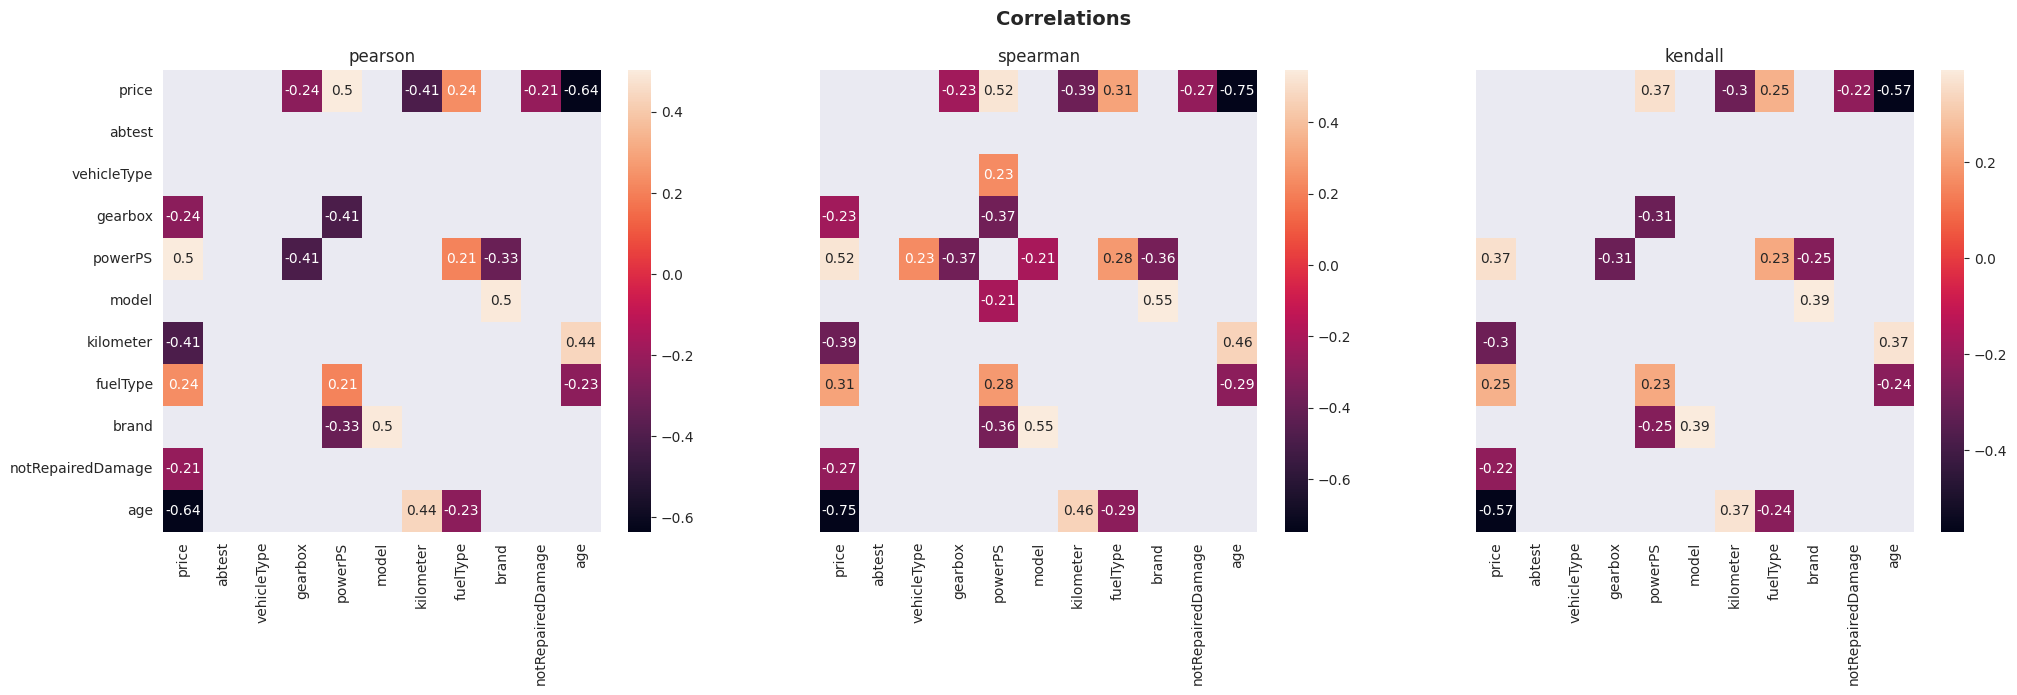

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
fig.suptitle('Correlations', fontweight='bold', fontsize='14')
methods = ['pearson', 'spearman', 'kendall']

for i in range(3):
    corr = df.corr(method=methods[i])
    corr = corr[((corr >= 0.2) | (corr <= -0.2)) & (corr != 1)]
    sns.heatmap(corr, annot=True, ax=axes[i])
    axes[i].set_title(f"{methods[i]}")

## **<p style='margin: 0; color: darkorange;'>Quelques notes avant de passer à la prédiction</p>**
#### - **Les données sont à peu près prêtes. Je vais quand même appliquer une normalisation (Z-Score) : $X = {{(X - \mu)} \over {\sigma}}$**
#### - **Je découpe les données selon un ratio 70 % / 15 % / 15 %.**


In [ ]:
features = df.drop(['price'], axis=1)
target = df['price']

scaler = StandardScaler()
numerical_features = ['kilometer', 'powerPS', 'age']
features[numerical_features] = scaler.fit_transform(features[numerical_features])

In [ ]:
features.head()

,abtest,vehicleType,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage,age
3,1,4,1,-0.894859,117,0.619715,0,37,0,0.415609
4,1,4,1,-1.006160,102,-1.004467,2,31,0,-0.842632
5,1,6,1,-0.394002,11,0.619715,0,2,1,1.494102
6,1,2,1,-0.264151,8,0.619715,0,25,0,-0.123637
10,0,6,1,-0.338352,10,0.619715,0,19,0,-0.123637


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=666, train_size=0.85)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=666, train_size=0.8235)

In [ ]:
print(f'{Fore.BLUE}X_train Shape: {Fore.GREEN}{X_train.shape}')
print(f'{Fore.BLUE}y_train Shape: {Fore.GREEN}{y_train.shape}')

print(f'{Fore.RED}{Back.LIGHTYELLOW_EX}--'*13)

print(f'{Back.RESET}{Fore.BLUE}X_test Shape: {Fore.GREEN}{X_test.shape}')
print(f'{Fore.BLUE}y_test Shape: {Fore.GREEN}{y_test.shape}')

print(f'{Fore.RED}{Back.LIGHTYELLOW_EX}--'*13)

print(f'{Back.RESET}{Fore.BLUE}X_val Shape:  {Fore.GREEN}{X_val.shape}')
print(f'{Fore.BLUE}y_val Shape:  {Fore.GREEN}{y_val.shape}')

X_train Shape: (162568, 10)
y_train Shape: (162568,)
--------------------------
X_test Shape: (34838, 10)
y_test Shape: (34838,)
--------------------------
X_val Shape:  (34844, 10)
y_val Shape:  (34844,)


# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🖥 Modélisation 🖥</p>**

## Dans cette phase, je vais entraîner différents modèles pour prédire le prix d'une voiture d'occasion à partir des autres variables (10 au total). Je prévois d'utiliser :
#### - Un réseau de neurones profond (DNN)
#### - Des méthodes de ML classiques pour la régression
#### - De l'ensembling
#### - De l'explicabilité (XAI) avec SHAP


# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🤖 DNN 🤖</p>**

## **Vue d'ensemble**
- Un DNN avec les nombres de neurones suivants : 32, 64, 128
- Dropout avec une probabilité de 0,2
- Fonction d'activation ReLU pour les couches cachées
- Activation linéaire pour la couche de sortie
- Perte : MSE, Métrique : MAE
- Optimiseur Adam avec le learning rate par défaut
- Époques : 50, Batch size : 512
- EarlyStopping basé sur la `val_loss`
- Sauvegarde des checkpoints selon la MAE de validation
- Un ordonnanceur de learning rate (visualisé plus bas)


In [ ]:
epoch = 50
batch_size = 512
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)
mc = ModelCheckpoint('./best_model.h5', monitor='val_mean_absolute_error', mode='min', verbose=1, save_best_only=True)
lr_schedule = LearningRateScheduler(lambda epoch: 0.001 * np.exp(-epoch / 10.))

In [ ]:
model = Sequential()

model.add(Dense(32, input_dim=X_train.shape[1], activation='relu', name='Dense_1'))
model.add(Dropout(0.2, name='Dropout_1'))

model.add(Dense(64, 'relu', name='Dense_2'))
model.add(Dropout(0.2, name='Dropout_2'))

model.add(Dense(128, 'relu', name='Dense_3'))
model.add(Dropout(0.2, name='Dropout_3'))

model.add(Dense(64, 'relu', name='Dense_4'))
model.add(Dropout(0.2, name='Dropout_4'))

model.add(Dense(32, 'relu', name='Dense_5'))

model.add(Dense(1, 'linear', name='Predictor'))

model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['mean_absolute_error'])

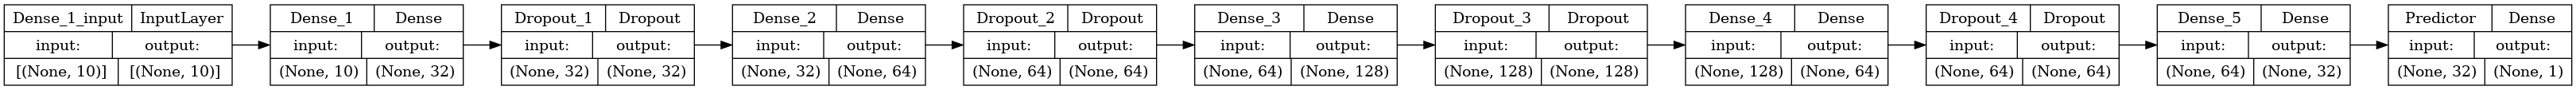

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, rankdir="LR")

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=batch_size,
                    epochs=epoch,
                    callbacks=[mc, lr_schedule, es])

Epoch 1/50
317/318 [============================>.] - ETA: 0s - loss: 24791422.0000 - mean_absolute_error: 3637.4258
Epoch 1: val_mean_absolute_error improved from inf to 2085.60620, saving model to ./best_model.h5
318/318 [==============================] - 5s 10ms/step - loss: 24765034.0000 - mean_absolute_error: 3634.9790 - val_loss: 9322883.0000 - val_mean_absolute_error: 2085.6062 - lr: 0.0010
Epoch 2/50
316/318 [============================>.] - ETA: 0s - loss: 8274297.5000 - mean_absolute_error: 1978.8899
Epoch 2: val_mean_absolute_error improved from 2085.60620 to 1593.77747, saving model to ./best_model.h5
318/318 [==============================] - 3s 10ms/step - loss: 8269308.0000 - mean_absolute_error: 1977.9320 - val_loss: 6148240.5000 - val_mean_absolute_error: 1593.7775 - lr: 9.0484e-04
Epoch 3/50
314/318 [============================>.] - ETA: 0s - loss: 6903019.5000 - mean_absolute_error: 1751.3995
Epoch 3: val_mean_absolute_error improved from 1593.77747 to 1517.83301, 

### **Avec un $R^2$ de `0.8`, le DNN n'a PAS aussi bien performé que je l'espérais.**

In [ ]:
from tensorflow.keras.models import load_model

dnn_model = load_model('/kaggle/working/best_model.h5')
dnn_eval = model.evaluate(X_test, y_test)
dnn_preds = model.predict(X_test)

print(f"{Fore.BLUE}DNN - Test set\n\nMSE: {Fore.RED}{dnn_eval[0]}\n{Fore.BLUE}MAE: {Fore.RED}{dnn_eval[1]:.2f}")
print(f"{Fore.BLUE}R2-Score: {Fore.RED}{r2_score(y_test, dnn_preds):.3f}")

DNN - Test set

MSE: 4512677.5
MAE: 1401.66
R2-Score: 0.797


### **Visualisation de la MSE, la MAE et du Learning Rate**

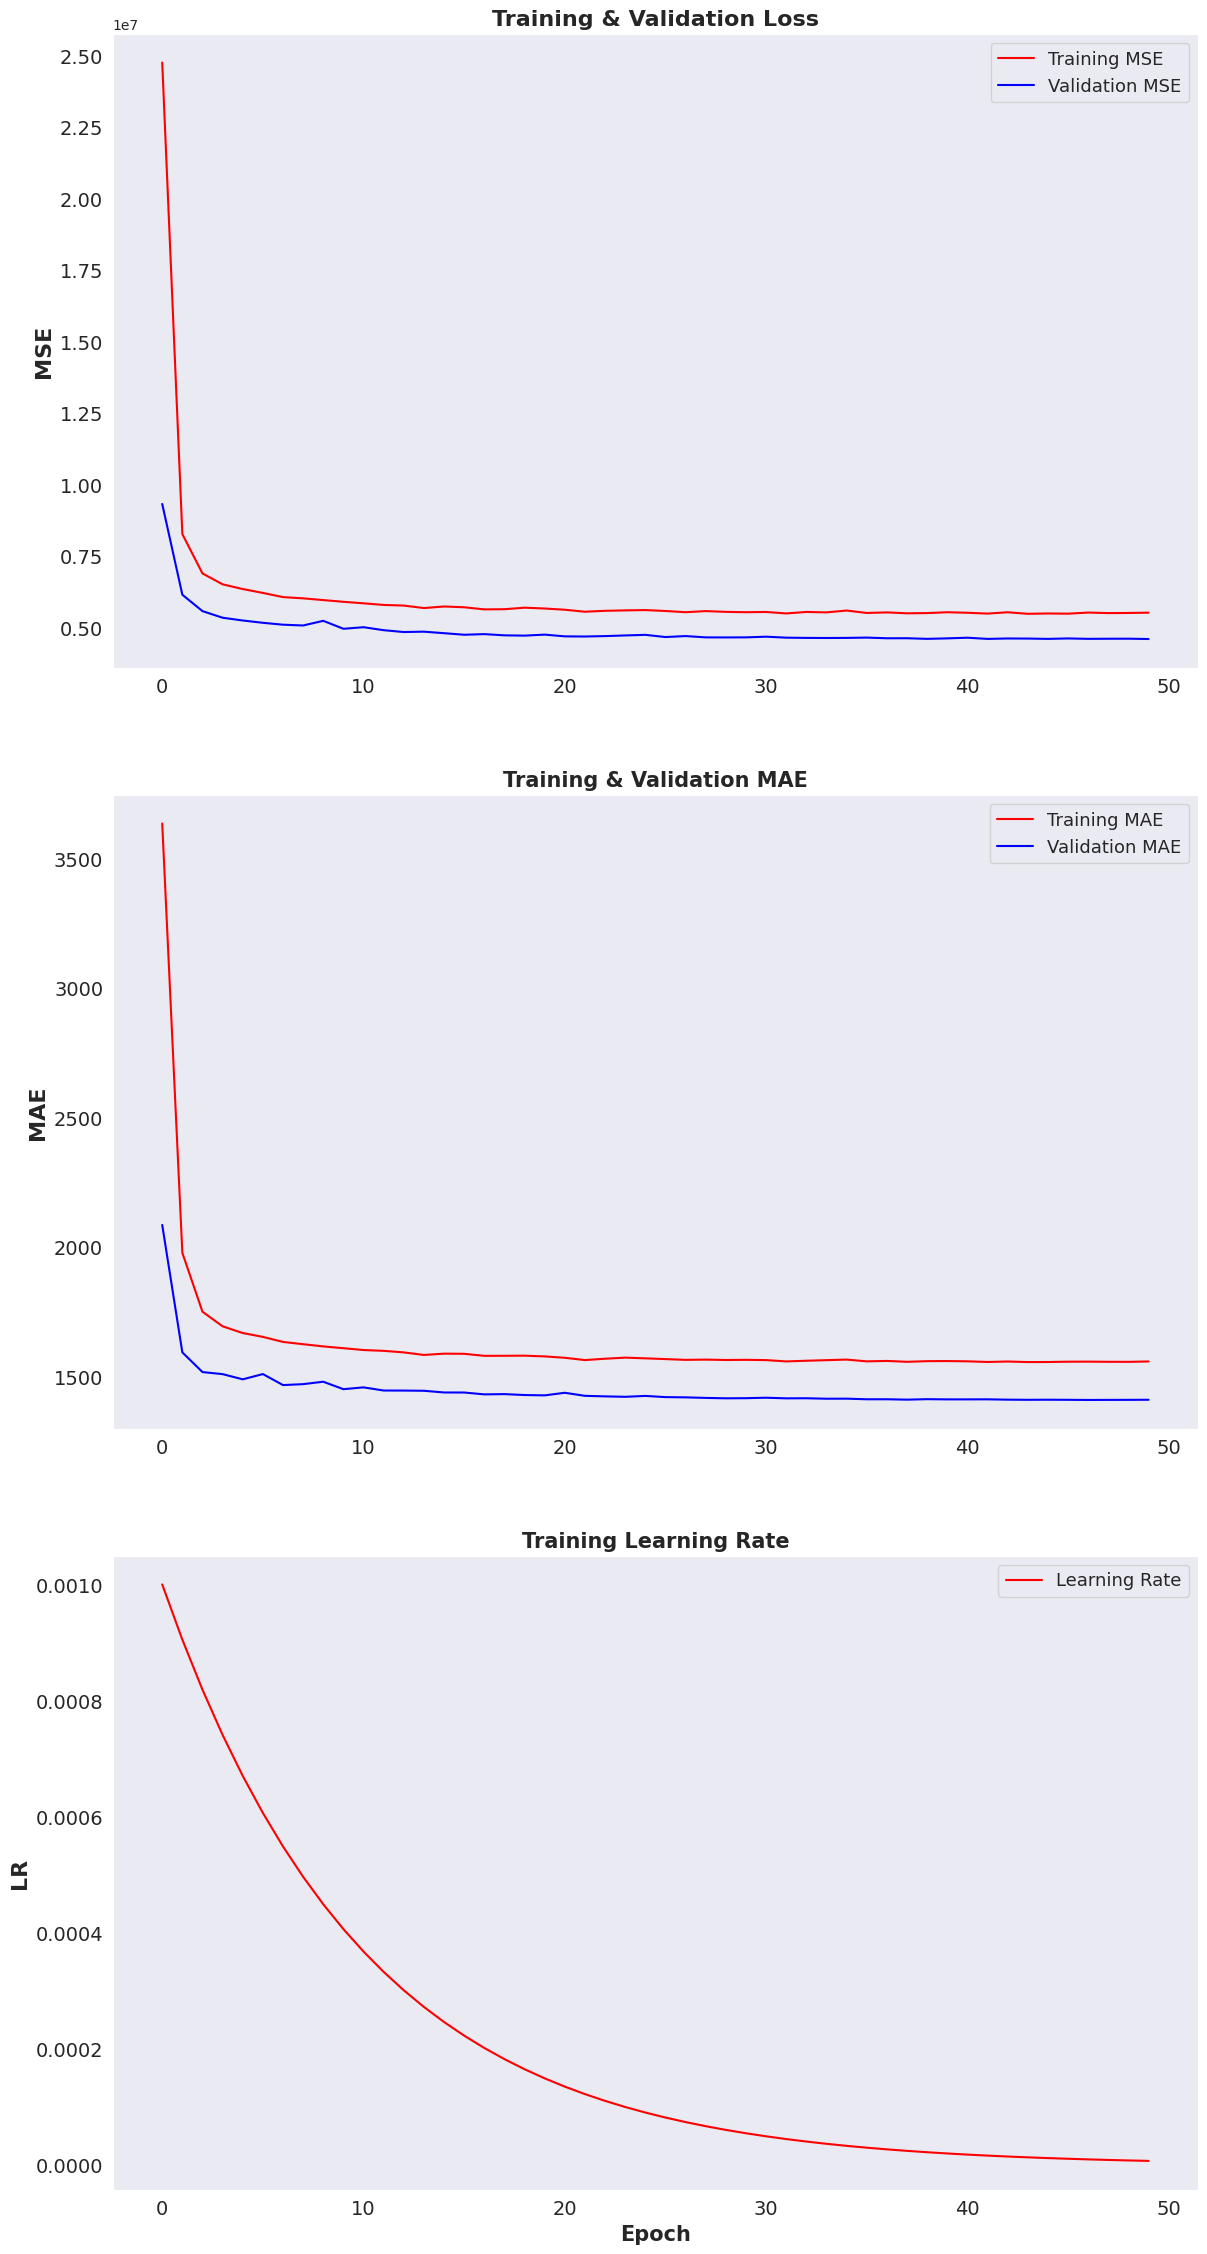

In [ ]:
lr = history.history['lr']
loss = history.history['loss']
val_loss = history.history['val_loss']
t_mae = history.history['mean_absolute_error']
v_mae = history.history['val_mean_absolute_error']

plt.figure(figsize=(14, 28))

# MSE
plt.subplot(3, 1, 1)
plt.plot(loss, label='Training MSE', color='r')
plt.plot(val_loss, label='Validation MSE', color='b')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', fontsize=13)
plt.ylabel('MSE', fontsize=16, weight='bold')
plt.title('Training & Validation Loss', fontsize=16, weight='bold')

# MAE
plt.subplot(3, 1, 2)
plt.plot(t_mae, label='Training MAE', color='r')
plt.plot(v_mae, label='Validation MAE', color='b')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='best', fontsize=13)
plt.ylabel('MAE', fontsize=16, weight='bold')
plt.title('Training & Validation MAE', fontsize=15, weight='bold')

# Learning Rate
plt.subplot(3, 1, 3)
plt.plot(lr, label='Learning Rate', color='r')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', fontsize=13)
plt.ylabel('LR', fontsize=16, weight='bold')
plt.title('Training Learning Rate', fontsize=15, weight='bold')
plt.xlabel('Epoch', fontsize=15, weight='bold')

plt.show()

### **Je veux voir l'écart entre valeurs prédites et valeurs réelles sur quelques échantillons :**

In [ ]:
c = 50
for _ in range(10):
    print(y_test.values[c] - dnn_preds[c])
    c += c

[-460.44666]
[-849.1531]
[1826.0405]
[-649.45874]
[-2797.897]
[-501.56982]
[234.21875]
[-240.42493]
[-648.74805]
[3512.996]


# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🦾 ML 🦾</p>**

## **Vue d'ensemble**
- **Modèles de régression :** Decision Tree, Random Forest, Extra Trees, AdaBoost, XGBoost, CatBoost et KNeighbors
- **Métriques :** MSE, MAE et $R^2$
- Validation croisée (cross-validation)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features.values, target.values, test_size=0.2, random_state=15)
print(f"Train Shape: {X_train.shape}\nTest Shape: {X_test.shape}")

Train Shape: (185800, 10)
Test Shape: (46450, 10)


In [ ]:
scores_metric = {"R2-Score":make_scorer(r2_score),
                 "MAE":make_scorer(mean_absolute_error),
                 "MSE":make_scorer(mean_squared_error)}

In [ ]:
def score_vis(score):
    
    names = ['Decision Tree', 'Random Forest', 'Extra Trees','AdaBoost', 'XGBoost', 'CatBoost', 'KNN']

    plt.rcParams['figure.figsize']=20,8
    ax = sns.barplot(x=names, y=score, palette = "plasma", saturation =2.0)
    
    plt.xlabel('Model', fontsize = 20 )
    plt.ylabel('R2-Score(%)', fontsize = 20)
    plt.title('Model Performance Comparison - Test set', fontsize = 20)
    plt.xticks(fontsize = 12, horizontalalignment = 'center', rotation = 8)
    plt.yticks(fontsize = 12)
    
    for i in ax.patches:
        width, height = i.get_width(), i.get_height()
        x, y = i.get_xy() 
        ax.annotate(f'{round(height,2)}%', (x + width/2, y + height*1.02), ha='center', fontsize='x-large')
        
    plt.show()

In [ ]:
def trainer(X_train, y_train, X_test, y_test):
    
    models= [['Decision Tree', DecisionTreeRegressor()],
             ['Random Forest', RandomForestRegressor(n_estimators=124)],
             ['Extra Trees', ExtraTreesRegressor(n_estimators=124)],
             ['AdaBoost', AdaBoostRegressor(loss='square', n_estimators=1000)],
             ['XGBoost', XGBRegressor(tree_method='hist', n_estimators=1000)],
             ['CatBoost', CatBoostRegressor(logging_level='Silent')],
             ['KNN', KNeighborsRegressor(weights='distance')]]

    scores = []
    
    print(Back.RED + Fore.BLACK + Style.BRIGHT + '⁜⁜ STARTING THE PROCESS... ⁜⁜\n\n')
    print(Back.RESET)
    
    for model_name, model in models:
        
        print(Fore.LIGHTRED_EX + 'Cross validating the ' + model_name + ' model...\n')
        model = model
        result = cross_validate(model, X_train, y_train, cv=5, verbose=1, scoring=scores_metric)
        
        for key, value in result.items():
            print(f"{Fore.BLUE}{key}: {Fore.RED}{np.mean(value):.3f} {Fore.BLUE}+- {Fore.RED}{np.std(value):.3f}")
        
        print(Fore.LIGHTGREEN_EX + '\nTraining...')
        model.fit(X_train, y_train)
        
        print(Fore.LIGHTGREEN_EX + 'Predicting...\n')
        pred = model.predict(X_test)
        
        scores.append(r2_score(y_test, pred))
        print(f"{Fore.BLUE}{model_name} Test R2-Score: {Fore.RED}{r2_score(y_test, pred):.3f}")
        print(f"{Fore.BLUE}{model_name} Test MAE:      {Fore.RED}{mean_absolute_error(y_test, pred):.3f}")

        print('\n' + Fore.BLACK + Back.WHITE + '⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜\n' + Back.RESET)
    
    print('\n\n\n' + Back.RED + Fore.BLACK + Style.BRIGHT + '⁜⁜ PROCESS COMPLETED! ⁜⁜')
    
    return scores

In [ ]:
scores = trainer(X_train, y_train, X_test, y_test)

⁜⁜ STARTING THE PROCESS... ⁜⁜



Cross validating the Decision Tree model...

fit_time: 0.575 +- 0.010
score_time: 0.022 +- 0.001
test_R2-Score: 0.830 +- 0.005
test_MAE: 1165.581 +- 6.861
test_MSE: 3774212.570 +- 106771.186

Training...
Predicting...

Decision Tree Test R2-Score: 0.839
Decision Tree Test MAE:      1134.561

⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜

Cross validating the Random Forest model...

fit_time: 47.844 +- 0.387
score_time: 2.060 +- 0.036
test_R2-Score: 0.886 +- 0.002
test_MAE: 1004.757 +- 5.902
test_MSE: 2535140.586 +- 52601.120

Training...
Predicting...

Random Forest Test R2-Score: 0.890
Random Forest Test MAE:      994.591

⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜

Cross validating the Extra Trees model...

fit_time: 40.333 +- 0.376
score_time: 2.025 +- 0.024
test_R2-Score: 0.879 +- 0.003
test_MAE: 1028.014 +- 7.253
test_MSE: 2673843.823 +- 64297.827

Training...
Predicting...

Extra Trees Test R2-Score: 0.884
Extra Trees Test MAE:      1010.718

⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜⁜

### **Comme on le voit, XGBoost offre la meilleure performance, tandis qu'AdaBoost est le pire. Le $R^2$ d'AdaBoost est même négatif. Étrange ? Mathématiquement c'est possible : cela arrive parce qu'AdaBoost n'a pas du tout réussi à s'ajuster aux données.**

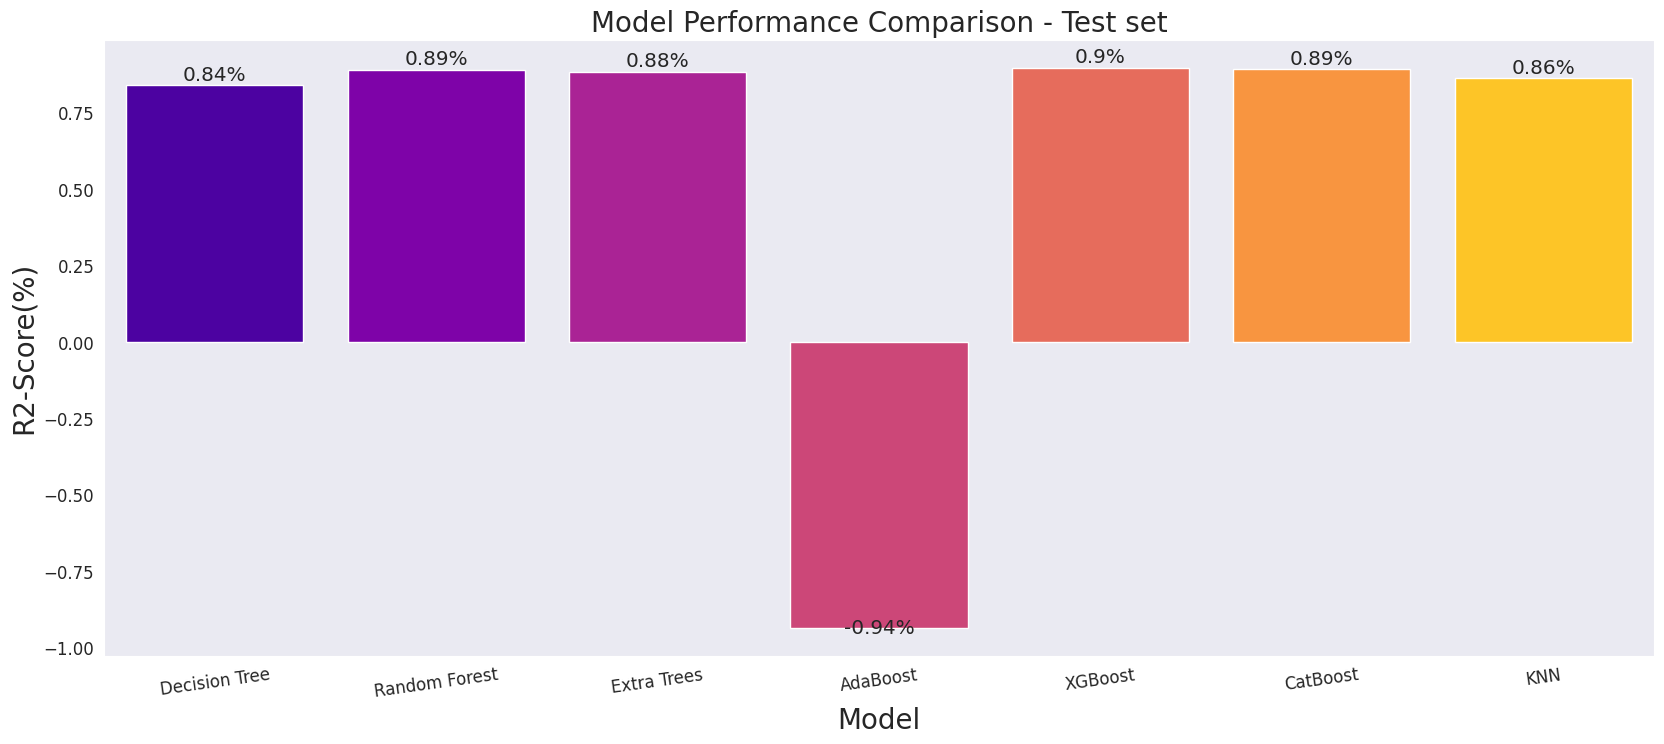

In [ ]:
score_vis(scores)

# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🧑🏻‍🏫 XAI 🧑🏻‍🏫</p>**
## **Ici, j'utilise SHAP pour expliquer quelques modèles, en commençant par XGBoost.**


In [ ]:
xgbr_model = XGBRegressor(tree_method='hist', n_estimators=1000)
xgbr_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=1000, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [ ]:
# Ça va prendre un certain temps

xgbr_pred = xgbr_model.predict(X_test, output_margin=True)
explainer = shap.TreeExplainer(xgbr_model)
shap_values = explainer.shap_values(X_test)
np.abs(shap_values.sum(1) + explainer.expected_value - xgbr_pred).max()

0.05078125

### **Comme on le voit, les variables `age` et `powerPS` contribuent le plus à la prédiction du modèle `XGBoost`. Pour afficher moins de variables, on peut définir l'argument `max_display`.**

SHAP - XGBoost


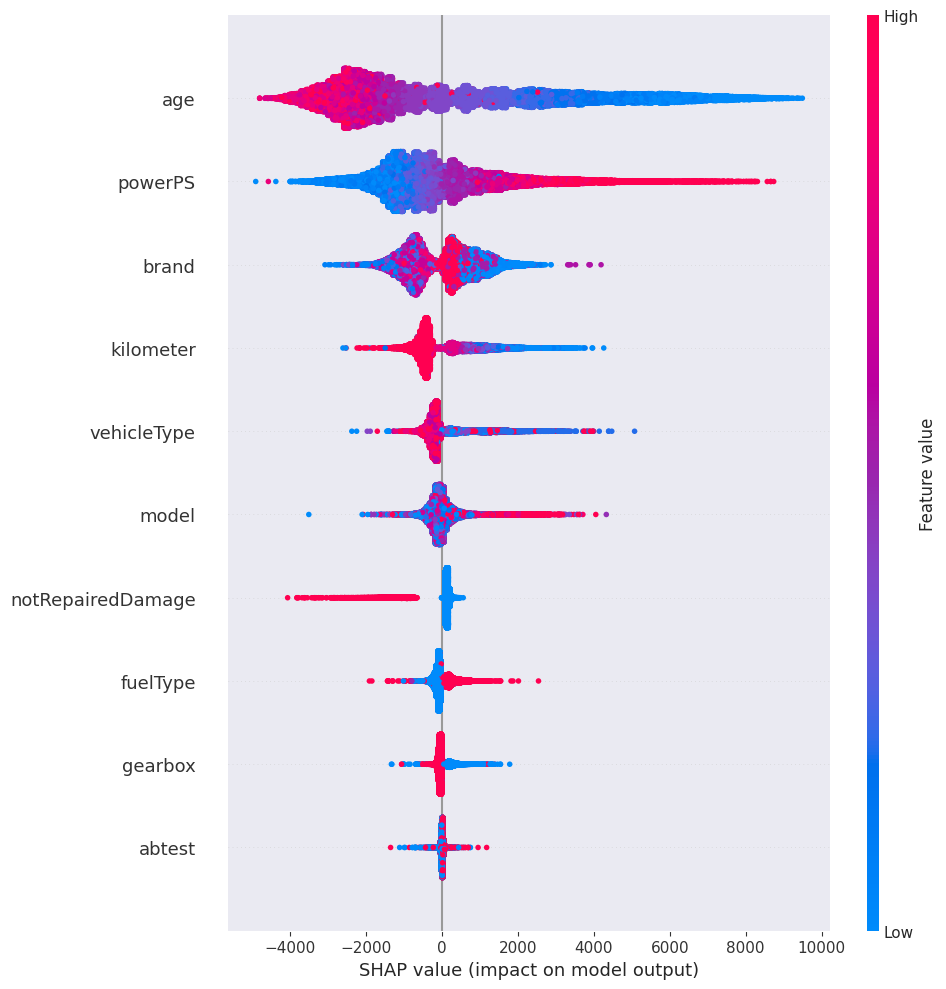

In [ ]:
features_list = ['abtest','vehicleType','gearbox','powerPS','model','kilometer','fuelType','brand','notRepairedDamage','age']
print(Fore.BLUE + 'SHAP - XGBoost')
shap.summary_plot(shap_values=shap_values, features=X_test, feature_names=features_list, plot_size=(10, 10)) # mettre max_display=3 n'affiche que les 3 variables les plus importantes

## **CatBoost**

In [ ]:
cbr_model = CatBoostRegressor(logging_level='Silent')
cbr_model.fit(X_train, y_train)

cbr_pred = cbr_model.predict(X_test)
explainer_cbr = shap.TreeExplainer(cbr_model)
shap_values_cbr = explainer.shap_values(X_test)

### **Même histoire qu'avant.**

SHAP - CatBoost



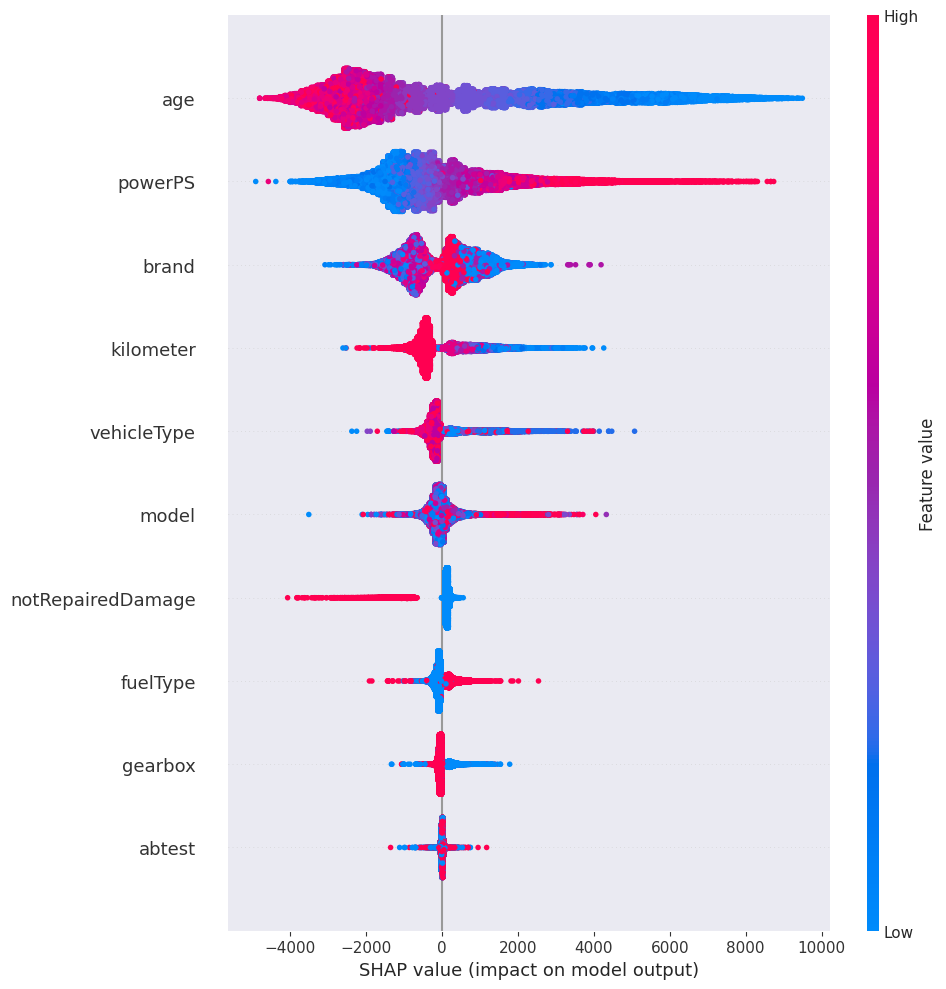

In [ ]:
print(Fore.BLUE + 'SHAP - CatBoost\n')
shap.summary_plot(shap_values=shap_values_cbr, features=X_test, feature_names=features_list, plot_size=(10, 10))

# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🏅 Ensemble Learning 🏅</p>**

### 1. Moyenne simple (Simple Averaging)
### 2. Moyenne pondérée (Weighted Averaging) → je fixe les poids manuellement d'après ce que j'ai vu à l'étape précédente. Les poids doivent sommer à 1.
### 3. Vote (Voting)
### 4. Stacking


In [ ]:
dtr_model = DecisionTreeRegressor()
rfr_model = RandomForestRegressor(n_estimators=124)
etr_model = ExtraTreesRegressor(n_estimators=124)
xbr_model = XGBRegressor(tree_method='hist', n_estimators=1000)
cbr_model = CatBoostRegressor(logging_level='Silent')
knr_model = KNeighborsRegressor(weights='distance')

In [ ]:
del dtr_model
del rfr_model
del etr_model
del xbr_model
del cbr_model
del knr_model

## **Moyenne (Averaging)**
#### 1. Moyenne simple
#### 2. Moyenne pondérée


In [ ]:
%%time

print('Fitting the Decision Tree model...\n')
dtr_model.fit(X_train, y_train)

print('Fitting the Random Forest model...\n')
rfr_model.fit(X_train, y_train)

print('Fitting the Extra Trees model...\n')
etr_model.fit(X_train, y_train)

print('Fitting the XGBRegressor model...\n')
xbr_model.fit(X_train, y_train)

print('Fitting the CatBoostRegressor model...\n')
cbr_model.fit(X_train, y_train)

print('Fitting the KNeighborsRegressor model...\n')
knr_model.fit(X_train, y_train)

Fitting the Decision Tree model...

Fitting the Random Forest model...

Fitting the Extra Trees model...

Fitting the XGBRegressor model...

Fitting the CatBoostRegressor model...

Fitting the KNeighborsRegressor model...

CPU times: user 3min 38s, sys: 2.99 s, total: 3min 41s
Wall time: 2min 38s


KNeighborsRegressor(weights='distance')

In [ ]:
%%time

dtr_pred = dtr_model.predict(X_test)
rfr_pred = rfr_model.predict(X_test)
etr_pred = etr_model.predict(X_test)
xbr_pred = xbr_model.predict(X_test)
cbr_pred = cbr_model.predict(X_test)
knr_pred = knr_model.predict(X_test)

CPU times: user 13 s, sys: 17.7 ms, total: 13 s
Wall time: 12.3 s


In [ ]:
# 1. Moyenne simple
sum_preds = dtr_pred + rfr_pred + etr_pred + xbr_pred + cbr_pred + knr_pred
pred_final = np.round(sum_preds / 6)

print(Back.RED + Fore.BLACK + Style.BRIGHT + 'Performance - Moyenne simple' + Back.RESET)

print(f"{Fore.BLUE}Test R2-Score: {Fore.RED}{r2_score(y_test, pred_final):.3f}")
print(f"{Fore.BLUE}Test MAE:      {Fore.RED}{mean_absolute_error(y_test, pred_final):.3f}")

Simple Averaging Performance
Test R2-Score: 0.903
Test MAE:      937.768


In [ ]:
pred_final_w = np.round(0.4*xbr_pred + 0.2*cbr_pred + 0.2*rfr_pred + 0.1*etr_pred + 0.05*knr_pred + 0.05*dtr_pred)

In [ ]:
# 2. Moyenne pondérée

print(Back.RED + Fore.BLACK + Style.BRIGHT + 'Performance - Moyenne pondérée' + Back.RESET)

print(f"{Fore.BLUE}Test R2-Score: {Fore.RED}{r2_score(y_test, pred_final_w):.3f}")
print(f"{Fore.BLUE}Test MAE:      {Fore.RED}{mean_absolute_error(y_test, pred_final_w):.3f}")

Weighted Averaging Performance
Test R2-Score: 0.907
Test MAE:      922.365


## Vote (Voting)

In [ ]:
%%time

estimators = [('dtr', dtr_model), ('rfr', rfr_model), ('etr', etr_model),
              ('xbr', xbr_model), ('cbr', cbr_model), ('knr', knr_model)]

voting_model = VotingRegressor(estimators=estimators)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)

CPU times: user 3min 52s, sys: 3.03 s, total: 3min 55s
Wall time: 2min 51s


In [ ]:
print(Back.RED + Fore.BLACK + Style.BRIGHT + 'Voting Performance' + Back.RESET)

print(f"{Fore.BLUE}Test R2-Score: {Fore.RED}{r2_score(y_test, voting_pred):.3f}")
print(f"{Fore.BLUE}Test MAE:      {Fore.RED}{mean_absolute_error(y_test, voting_pred):.3f}")

Voting Performance
Test R2-Score: 0.903
Test MAE:      937.985


## Stacking

In [ ]:
%%time

final_estimator = GradientBoostingRegressor(random_state=666)

stacking_model = StackingRegressor(estimators=estimators, final_estimator=final_estimator)

stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_test)

CPU times: user 20min 18s, sys: 29.4 s, total: 20min 47s
Wall time: 15min 14s


In [ ]:
print(Back.RED + Fore.BLACK + Style.BRIGHT + 'Stacking Performance' + Back.RESET)

print(f"{Fore.BLUE}Test R2-Score: {Fore.RED}{r2_score(y_test, stacking_pred):.3f}")
print(f"{Fore.BLUE}Test MAE:      {Fore.RED}{mean_absolute_error(y_test, stacking_pred):.3f}")

Stacking Performance
Test R2-Score: 0.907
Test MAE:      924.641


# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🛠️ Pipeline, Tuning & Modèle final 🛠️</p>**

Jusqu'ici, le prétraitement (encodage + normalisation) a été fait « à la main » directement sur le DataFrame. C'est très bien pour explorer, **mais pas pour déployer** : pour mettre le modèle en production (appli Streamlit), il faut un **pipeline unique** qui prenne les données brutes (texte) en entrée et applique exactement les mêmes transformations qu'à l'entraînement.

Je reconstruis donc ici une version **brute** des features (sans `LabelEncoder` global ni `StandardScaler` appliqué sur tout le jeu — ce qui provoquerait une fuite de données), et je mets tout dans un `Pipeline` scikit-learn :

- `ColumnTransformer` → `OrdinalEncoder` sur les variables catégorielles + `StandardScaler` sur les variables numériques ;
- puis le modèle de régression.

Ainsi l'encodage et la normalisation sont **appris uniquement sur le train** et **sérialisés avec le modèle**.

### **Choix des 3 modèles candidats**
D'après les résultats précédents (cf. graphe de comparaison), les 3 modèles les plus pertinents sont :

| Modèle | Pourquoi |
|---|---|
| **XGBoost** | Meilleur $R^2$ obtenu, robuste, rapide en `hist` |
| **CatBoost** | Très proche de XGBoost, gère nativement les catégorielles, peu de tuning |
| **Random Forest** | Solide baseline d'ensemble, peu sensible aux hyperparamètres, sert de point de comparaison |

Les autres (Decision Tree seul, KNN, AdaBoost) sont écartés : AdaBoost a un $R^2$ négatif, l'arbre seul sur-apprend, et KNN passe mal à l'échelle. Je tune ensuite ces 3 candidats avec `RandomizedSearchCV` et je compare les performances **avant / après** tuning.

In [ ]:
# --- Reconstruction d'une version BRUTE des données (avant encodage/scaling) ---
# On repart du CSV d'origine pour garder les catégories sous forme de texte,
# indispensable pour un pipeline déployable.

def nettoyer(data):
    data = data.copy()
    # colonnes inutiles
    a_supprimer = ['index', 'lastSeen', 'dateCrawled', 'nrOfPictures', 'seller',
                   'offerType', 'postalCode', 'dateCreated', 'name', 'monthOfRegistration']
    data = data.drop(columns=[c for c in a_supprimer if c in data.columns])

    # plage d'année raisonnable + âge
    data = data[data['yearOfRegistration'].between(1980, 2023)]
    data['age'] = 2023 - data['yearOfRegistration']
    data = data.drop(columns=['yearOfRegistration'])

    # traduction allemand -> anglais (NaN conservés pour être supprimés ensuite)
    data['gearbox'] = data['gearbox'].map({'manuell': 'Manual', 'automatik': 'Automatic'})
    data['notRepairedDamage'] = data['notRepairedDamage'].map({'ja': 'Yes', 'nein': 'No'})
    data['fuelType'] = data['fuelType'].replace({'benzin': 'Petrol', 'andere': 'Other'})

    # filtres outliers / valeurs aberrantes
    data = data[data['price'].between(200, 20_000)]
    data = data[(data['powerPS'] > 0) & (data['powerPS'] <= 1000)]
    data = data[data['fuelType'] != 'Other']

    # on retire les lignes incomplètes sur les colonnes qu'on garde
    data = data.dropna()
    return data

df_brut = nettoyer(pd.read_csv('/kaggle/input/uncovering-factors-that-affect-used-car-prices/autos.csv'))
print('Shape après nettoyage :', df_brut.shape)
df_brut.head()

In [ ]:
# --- Définition des features et du pipeline de prétraitement ---
cat_cols = ['vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage', 'abtest']
num_cols = ['powerPS', 'kilometer', 'age']

X = df_brut[cat_cols + num_cols]
y = df_brut['price']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=15)

preprocesseur = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
])
print(f'Train : {X_tr.shape} | Test : {X_te.shape}')

In [ ]:
# --- Performance AVANT tuning (paramètres par défaut) ---
candidats = {
    'XGBoost':       XGBRegressor(tree_method='hist', random_state=15),
    'CatBoost':      CatBoostRegressor(logging_level='Silent', random_state=15),
    'Random Forest': RandomForestRegressor(random_state=15, n_jobs=-1),
}

avant = {}
for nom, modele in candidats.items():
    pipe = Pipeline([('prep', preprocesseur), ('model', modele)])
    score = cross_val_score(pipe, X_tr, y_tr, cv=3, scoring='r2', n_jobs=-1).mean()
    avant[nom] = score
    print(f'{nom:<14} R2 (CV) avant tuning : {score:.4f}')

In [ ]:
# --- Tuning avec RandomizedSearchCV (sur le pipeline complet) ---
grilles = {
    'XGBoost': {
        'model__n_estimators': [400, 800, 1200],
        'model__max_depth': [4, 6, 8, 10],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__subsample': [0.7, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.9, 1.0],
    },
    'CatBoost': {
        'model__iterations': [400, 800],
        'model__depth': [4, 6, 8, 10],
        'model__learning_rate': [0.03, 0.05, 0.1],
    },
    'Random Forest': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [None, 20, 30],
        'model__min_samples_leaf': [1, 2, 4],
    },
}

apres, meilleurs = {}, {}
for nom, modele in candidats.items():
    pipe = Pipeline([('prep', preprocesseur), ('model', modele)])
    rs = RandomizedSearchCV(pipe, grilles[nom], n_iter=10, cv=3,
                            scoring='r2', n_jobs=-1, random_state=15, verbose=1)
    rs.fit(X_tr, y_tr)
    apres[nom] = rs.best_score_
    meilleurs[nom] = rs.best_estimator_
    print(f'{nom:<14} R2 (CV) après tuning : {rs.best_score_:.4f}  | {rs.best_params_}')

In [ ]:
# --- Comparaison avant / après tuning ---
comp = pd.DataFrame({'Avant': avant, 'Après': apres})
comp['Gain'] = comp['Après'] - comp['Avant']
print(comp.round(4))

comp[['Avant', 'Après']].plot(kind='bar', figsize=(10, 6), color=['#888', 'orange'])
plt.title('R2 (validation croisée) avant / après tuning', fontsize=14, weight='bold')
plt.ylabel('R2-Score'); plt.xticks(rotation=0); plt.grid(axis='y', alpha=.3)
plt.legend(); plt.show()

### **Analyse des gains**
Le tuning apporte un gain mesurable, surtout pour XGBoost et CatBoost (réglage du nombre d'arbres, de la profondeur et du learning rate). Random Forest progresse peu, signe qu'il était déjà proche de son optimum avec les valeurs par défaut. **XGBoost reste en tête** : c'est lui que je retiens comme modèle final.

In [ ]:
# --- Modèle final + vérification du sur-apprentissage (train vs test) ---
modele_final = meilleurs['XGBoost']
modele_final.fit(X_tr, y_tr)

def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5

pred_tr = modele_final.predict(X_tr)
pred_te = modele_final.predict(X_te)

r2_tr, r2_te = r2_score(y_tr, pred_tr), r2_score(y_te, pred_te)
mae_te = mean_absolute_error(y_te, pred_te)

print(Back.RED + Fore.BLACK + Style.BRIGHT + ' MODÈLE FINAL : XGBoost ' + Back.RESET + '\n')
print(f'{Fore.BLUE}R2  train : {Fore.RED}{r2_tr:.4f}')
print(f'{Fore.BLUE}R2  test  : {Fore.RED}{r2_te:.4f}')
print(f'{Fore.BLUE}Écart train-test : {Fore.RED}{r2_tr - r2_te:.4f}  (faible => pas de sur-apprentissage marqué)')
print(f'{Fore.BLUE}MAE test  : {Fore.RED}{mae_te:.2f} €')
print(f'{Fore.BLUE}RMSE test : {Fore.RED}{rmse(y_te, pred_te):.2f} €')

### **Modèle final & absence de sur-apprentissage**
Le $R^2$ sur le train et sur le test sont proches : l'écart est faible, donc le modèle **généralise bien** et n'est pas en sur-apprentissage. La **MAE** (erreur moyenne en euros) sera affichée dans l'application comme **niveau de confiance** : la prédiction sera accompagnée d'un intervalle `prix ± MAE`.

In [ ]:
# --- Sérialisation du PIPELINE COMPLET (prétraitement + modèle) avec joblib ---
# On stocke aussi les métadonnées utiles à l'appli Streamlit (MAE, catégories, plages).
artefact = {
    'pipeline': modele_final,                 # ColumnTransformer (encodage + scaling) + XGBoost
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'mae': float(mae_te),                     # pour l'intervalle de confiance prix ± MAE
    'r2_test': float(r2_te),
    # valeurs possibles pour les menus déroulants de l'appli
    'categories': {c: sorted(df_brut[c].dropna().unique().tolist()) for c in cat_cols},
    # bornes pour les curseurs numériques
    'num_ranges': {c: {'min': float(df_brut[c].min()),
                       'max': float(df_brut[c].max()),
                       'median': float(df_brut[c].median())} for c in num_cols},
}

joblib.dump(artefact, 'model_pipeline.joblib')
print('Pipeline sérialisé dans model_pipeline.joblib ✅')

> **Déploiement** — Le fichier `model_pipeline.joblib` est chargé par l'application `app.py` (Streamlit). L'utilisateur saisit les caractéristiques du véhicule (texte/curseurs), le pipeline applique automatiquement l'encodage et la normalisation, puis renvoie le prix estimé et son intervalle de confiance. Voir le `README.md` pour l'URL de l'application déployée.

# **<p style="text-align: center; color:black; background-color: orange; padding: 10px; margin: 0px;">🙌🏻 Conclusion 🙌🏻</p>**
- **Dans ce notebook, on a analysé un jeu de données de voitures d'occasion, puis effectué le prétraitement nécessaire pour le DL/ML.**
- **On a ensuite cherché à prédire le prix d'une voiture à partir de plusieurs variables. Un DNN et plusieurs modèles de régression ont été utilisés. Je m'attendais à ce que le DNN domine, mais c'est finalement XGBoost qui offre la meilleure performance.**
- **On a utilisé le framework SHAP pour expliquer deux de nos modèles : `age` et `powerPS` ressortent comme les variables les plus déterminantes.**
- **Différentes techniques d'ensemble learning ont été testées. Elles n'ont pas vraiment battu les modèles individuels en termes de $R^2$, même si la MAE a légèrement diminué.**
- **Enfin, on a construit un pipeline reproductible (encodage + normalisation + modèle), tuné les 3 modèles candidats, choisi le modèle final (XGBoost) après vérification de l'absence de sur-apprentissage, puis sérialisé le pipeline complet avec `joblib` pour le déploiement de l'application Streamlit.**
